**Tutoriel sur la classe `StatUnivariee`**
=====================================================

**Introduction**
---------------

La classe `StatUnivariee` est une classe Python qui permet de réaliser des analyses univariées de données. Elle est conçue pour être utilisée avec des données Pandas. L'objectif est d'avoir tout à portée de main pour les analyses de première intentions sans négliger l'aspect visuel pour autant. Une interface codée en HTML permet de disposer des différentes analyses universées des colonnes d'un dataframe sur un même espace.


**Création d'une instance de `StatUnivariee`**
---------------------------------------------

Pour créer une instance de `StatUnivariee`, il suffit de passer les arguments suivants :

* `datafram` : un DataFrame ou une série Pandas contenant les données à analyser.
* `hue` : une série Pandas catégorielle optionnelle. Si cette variable est utilisée, le dataframe ou la série précédente sera décomposé en fonction de chaque catégorie. L'analyse univariée se fera sur chacune de ces catégories puis sera restitué sur la même figure.

100%|██████████| 3/3 [00:01<00:00,  1.87series/s]



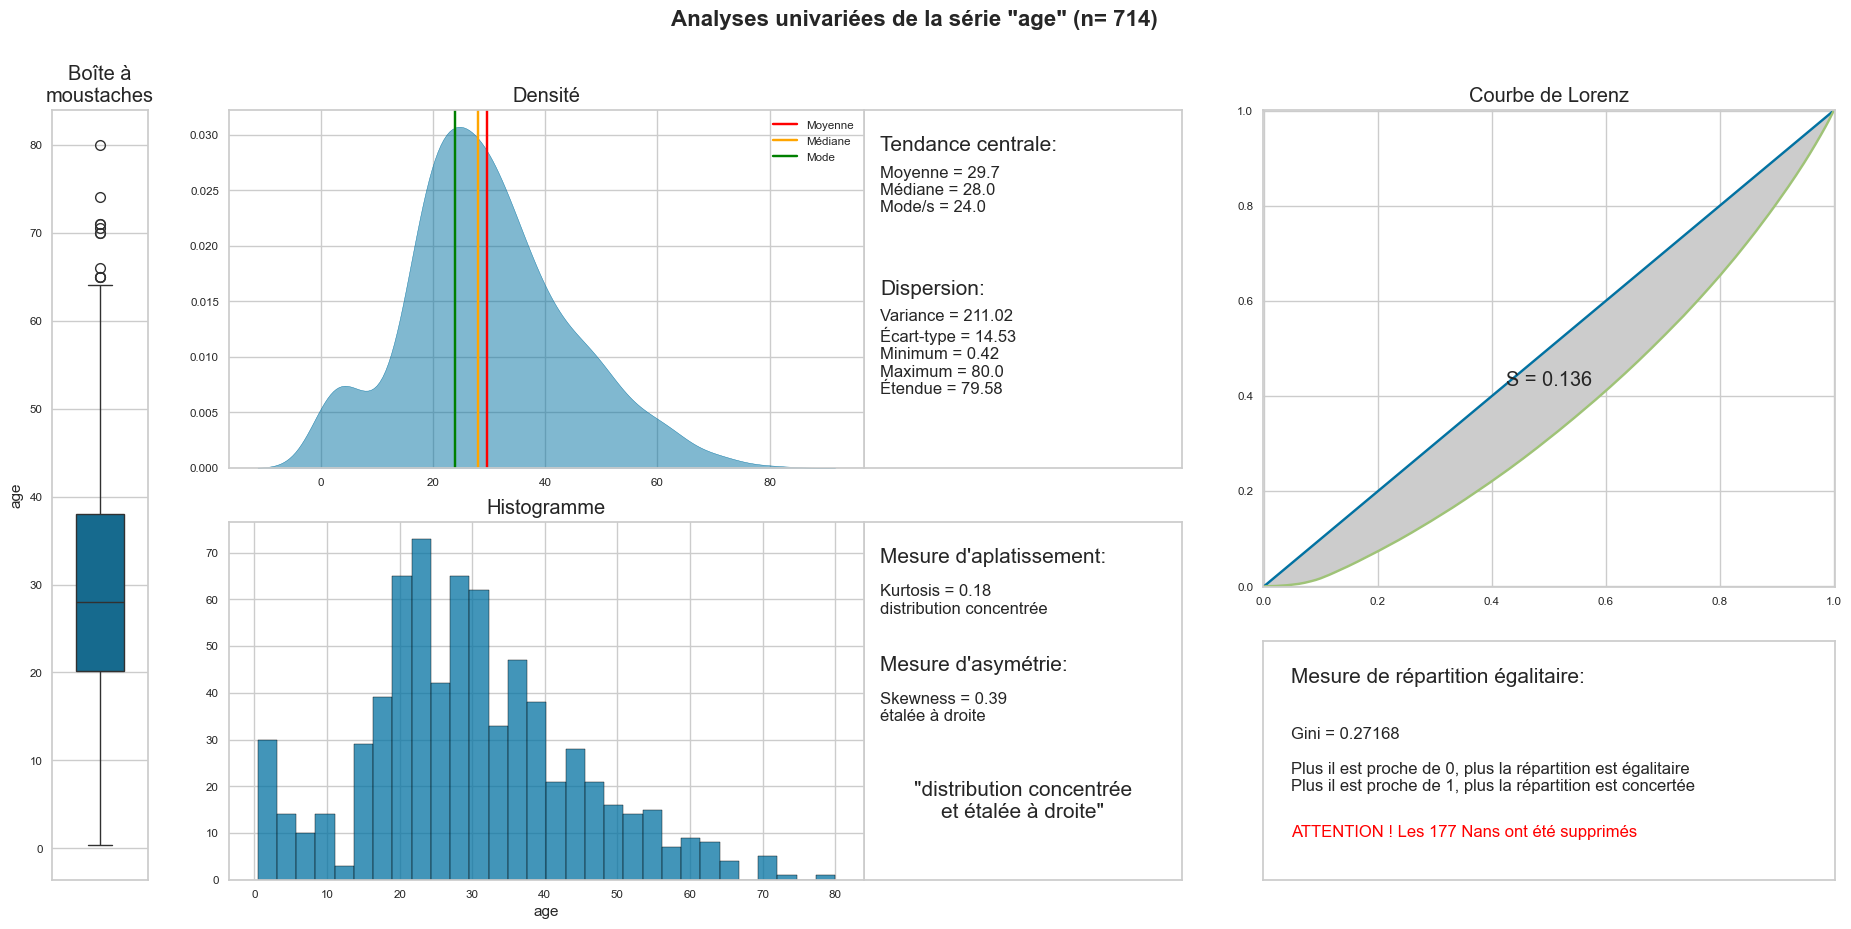
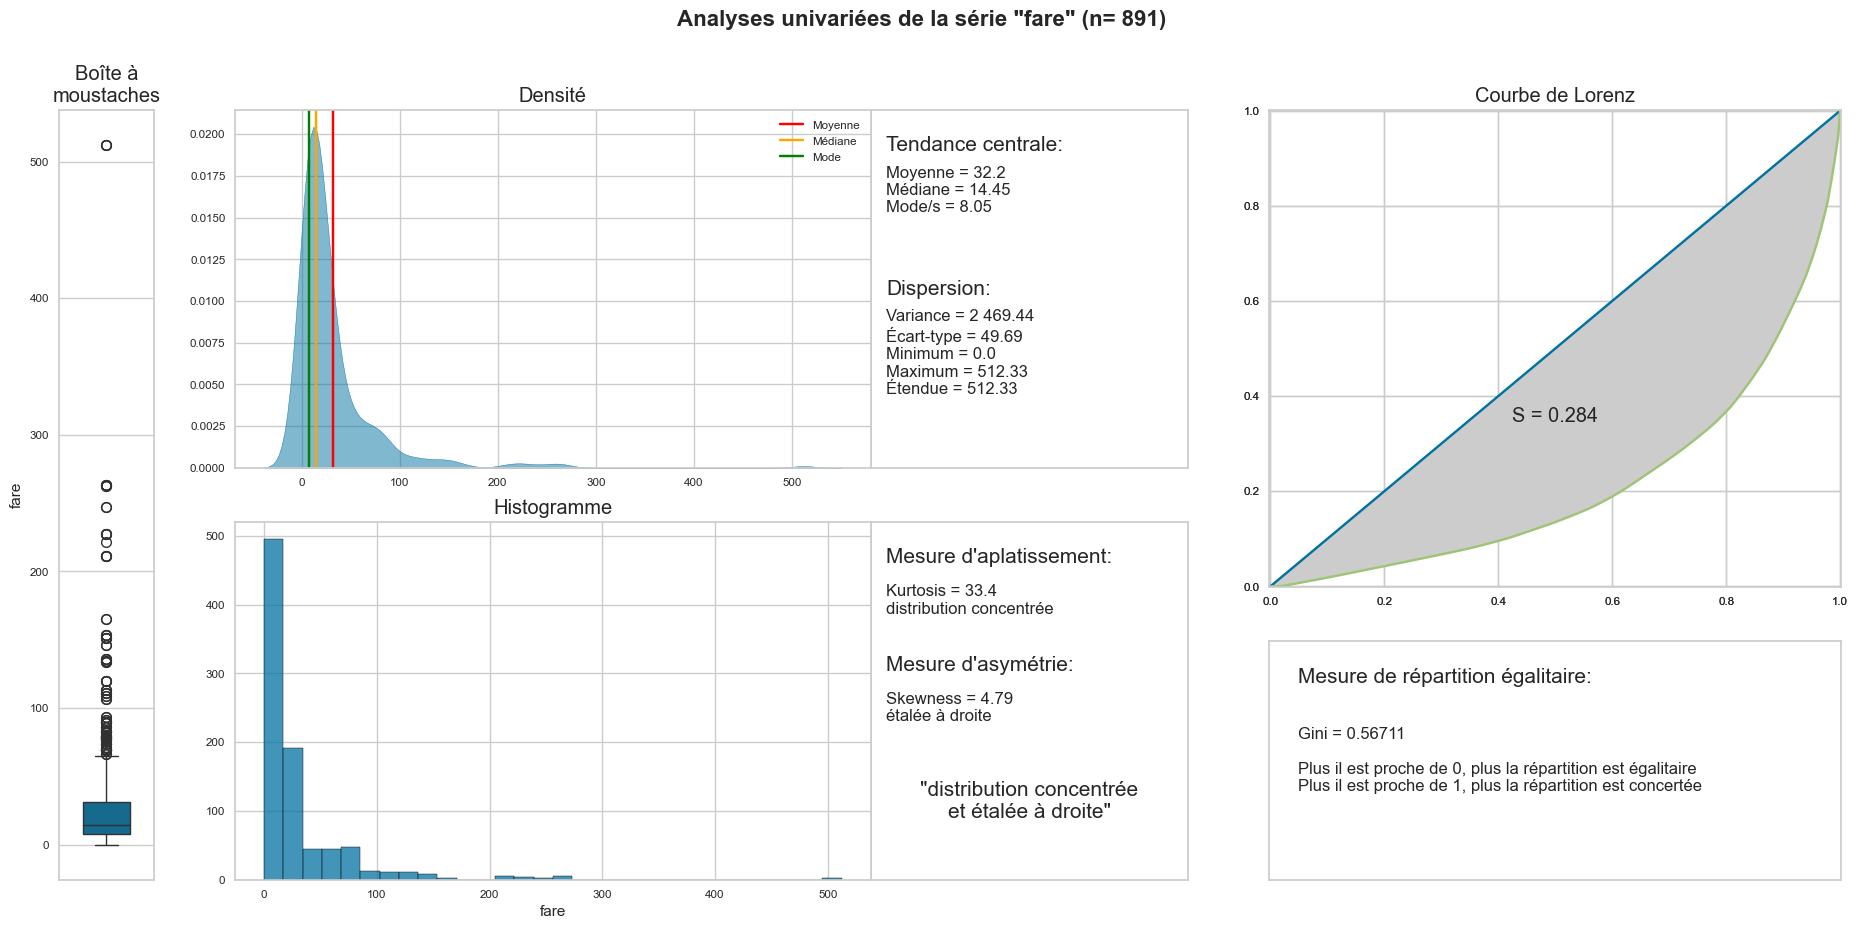
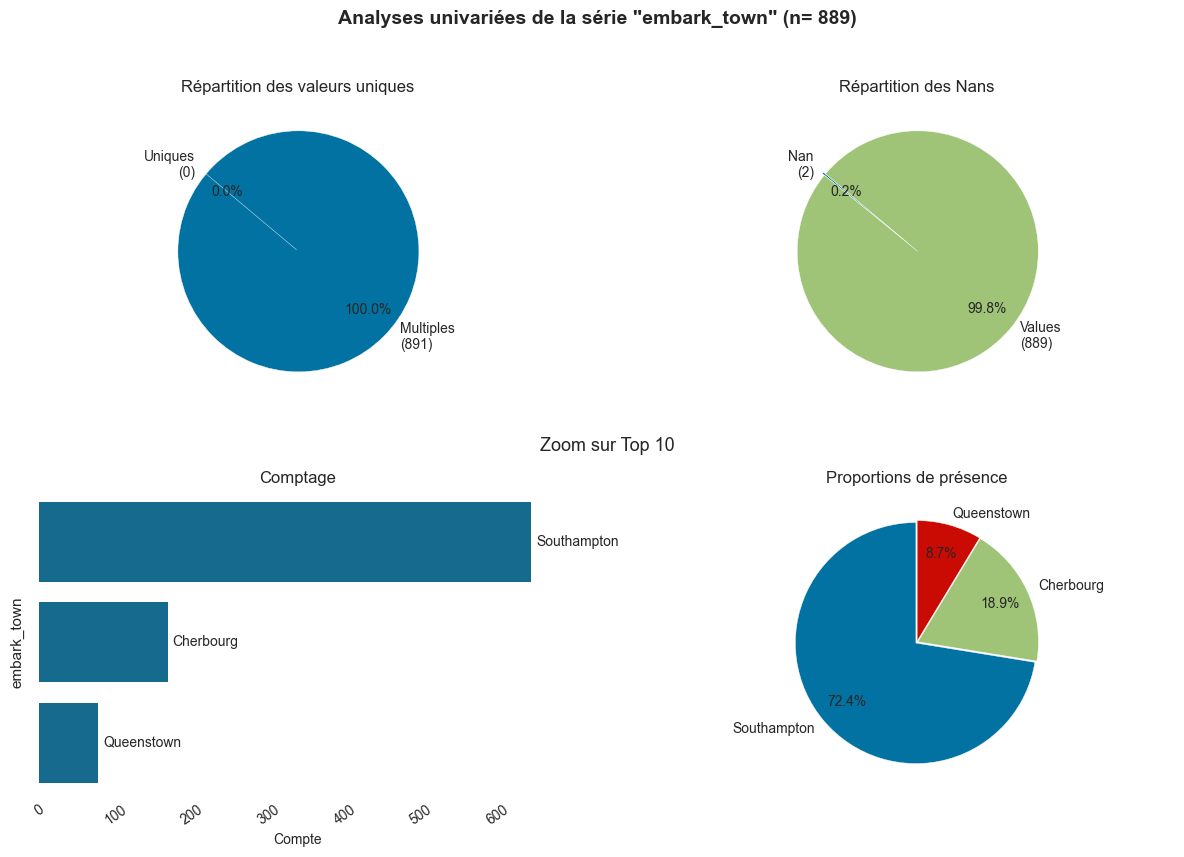
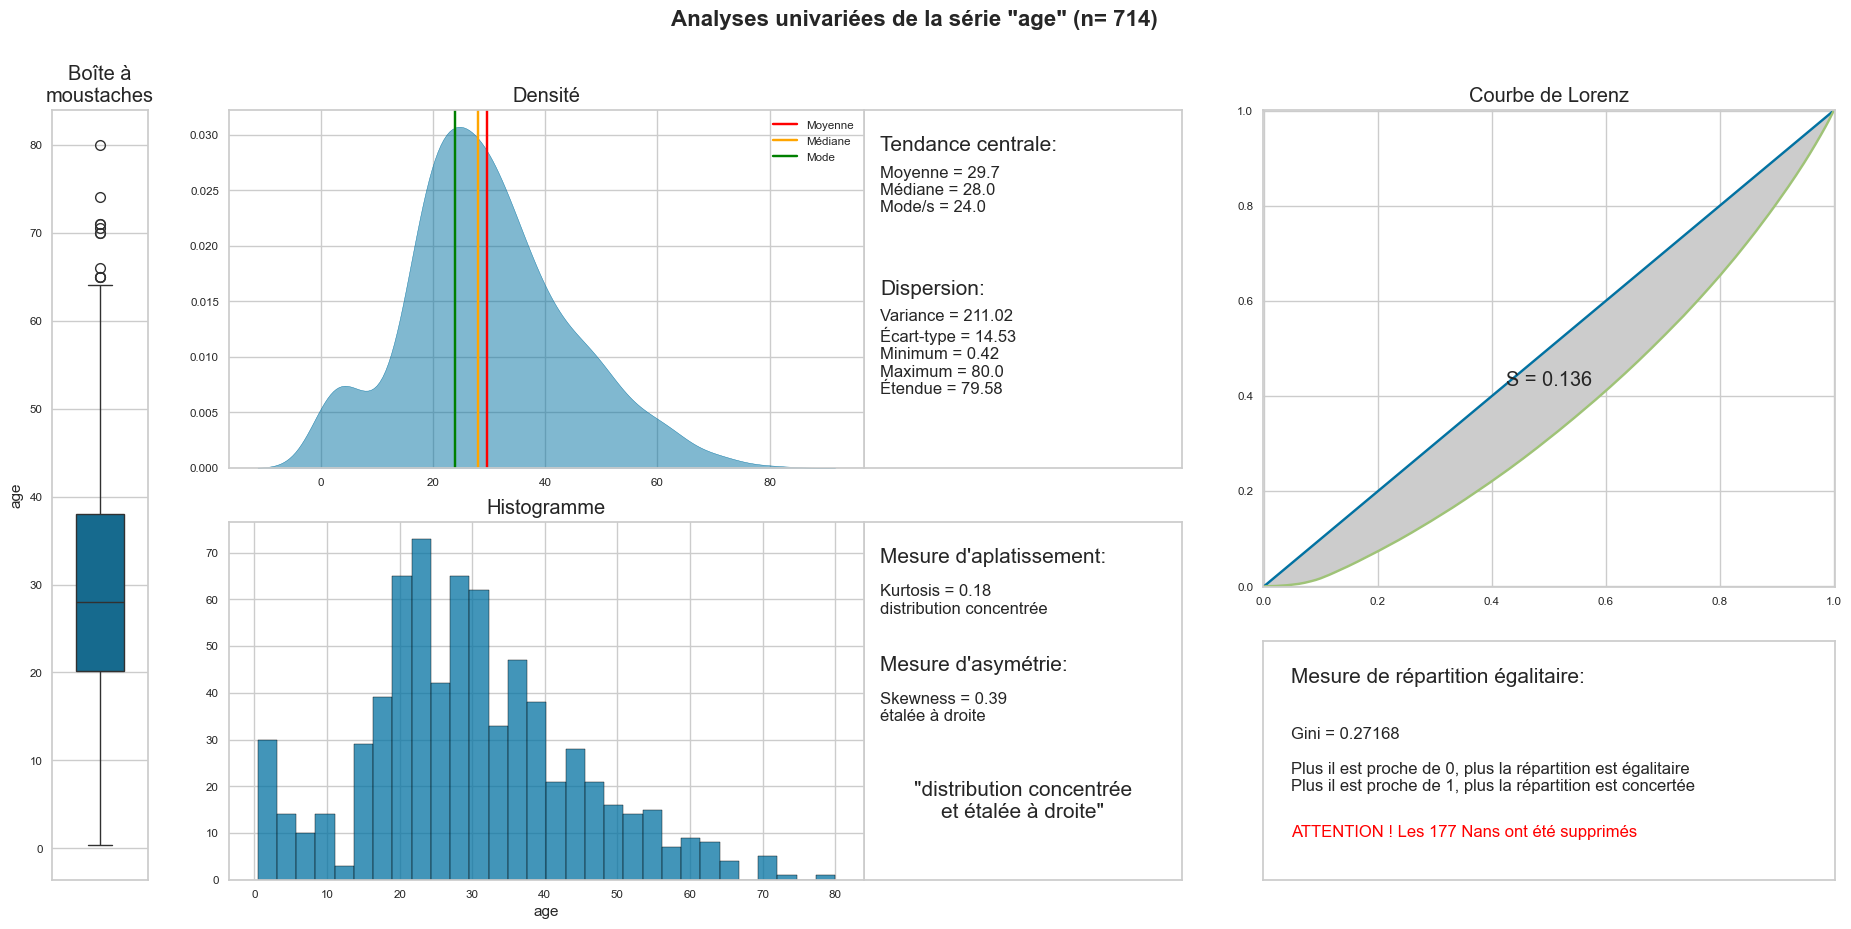

In [1]:
import seaborn as sns
from stat_univar import StatUnivariee

# Charger le dataset Titanic intégré dans seaborn
df = sns.load_dataset('titanic')

# Création d'une instance de StatUnivariee
fig = StatUnivariee(df.loc[:, ['age', 'fare', 'embark_town']])
fig

100%|██████████| 3/3 [00:02<00:00,  1.33series/s]



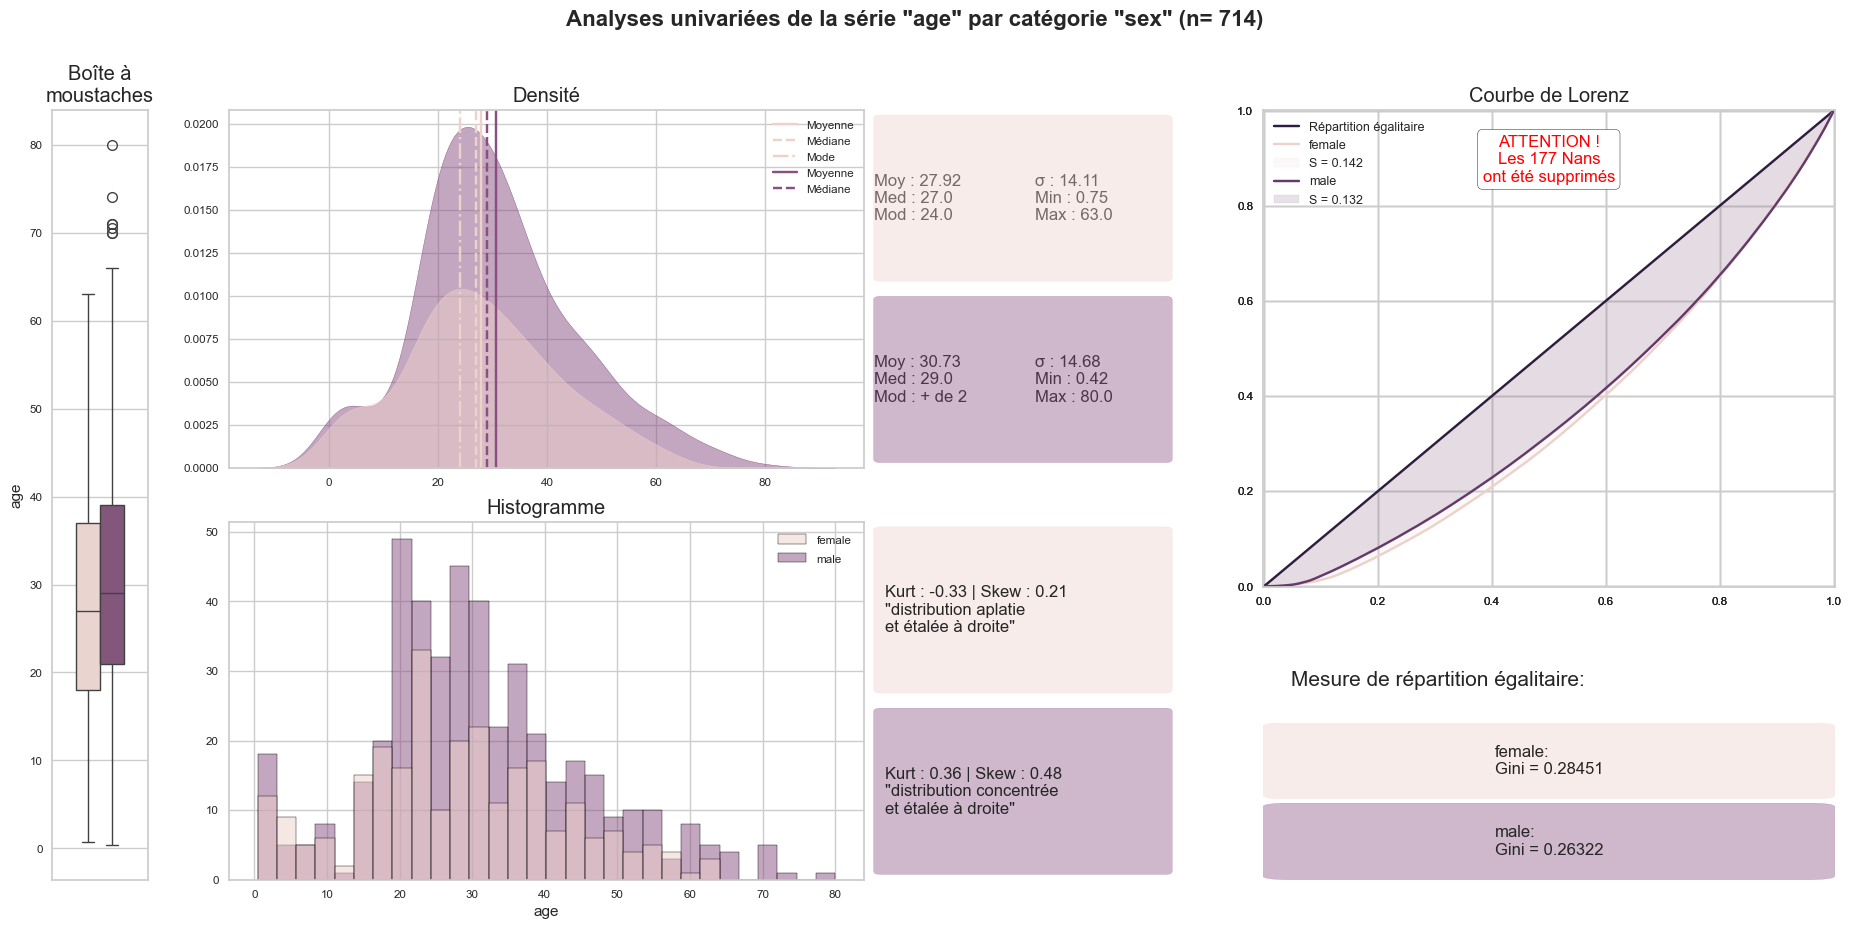
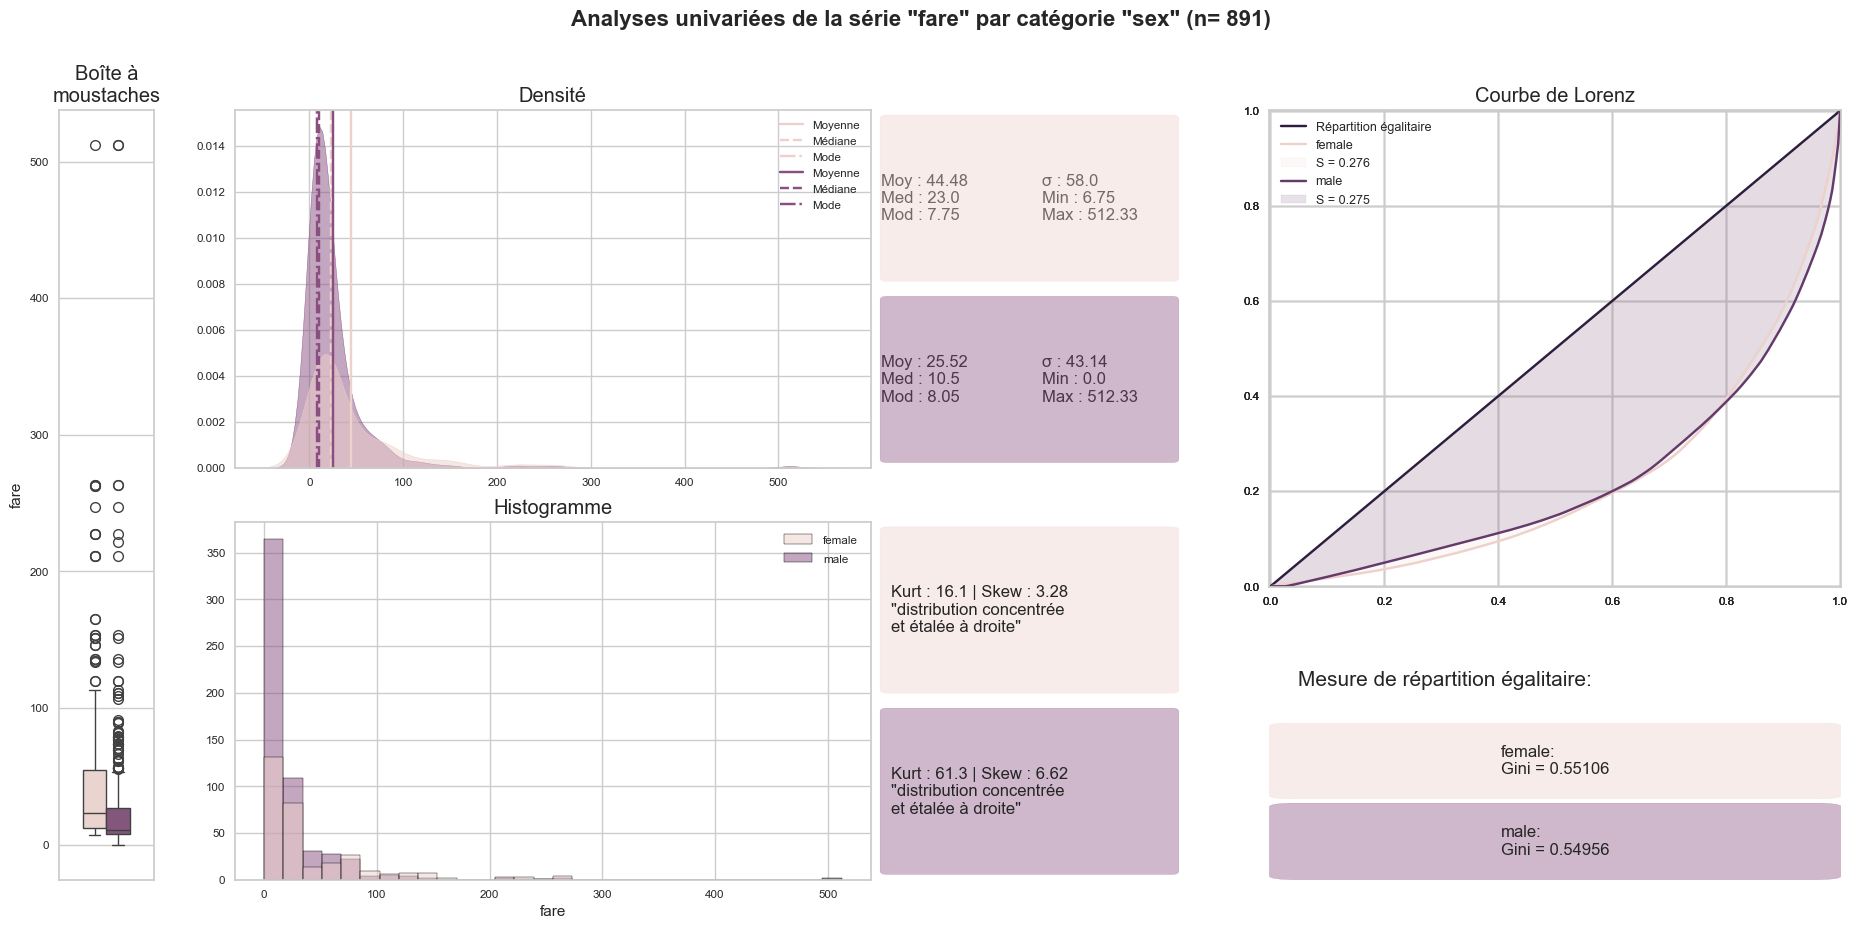
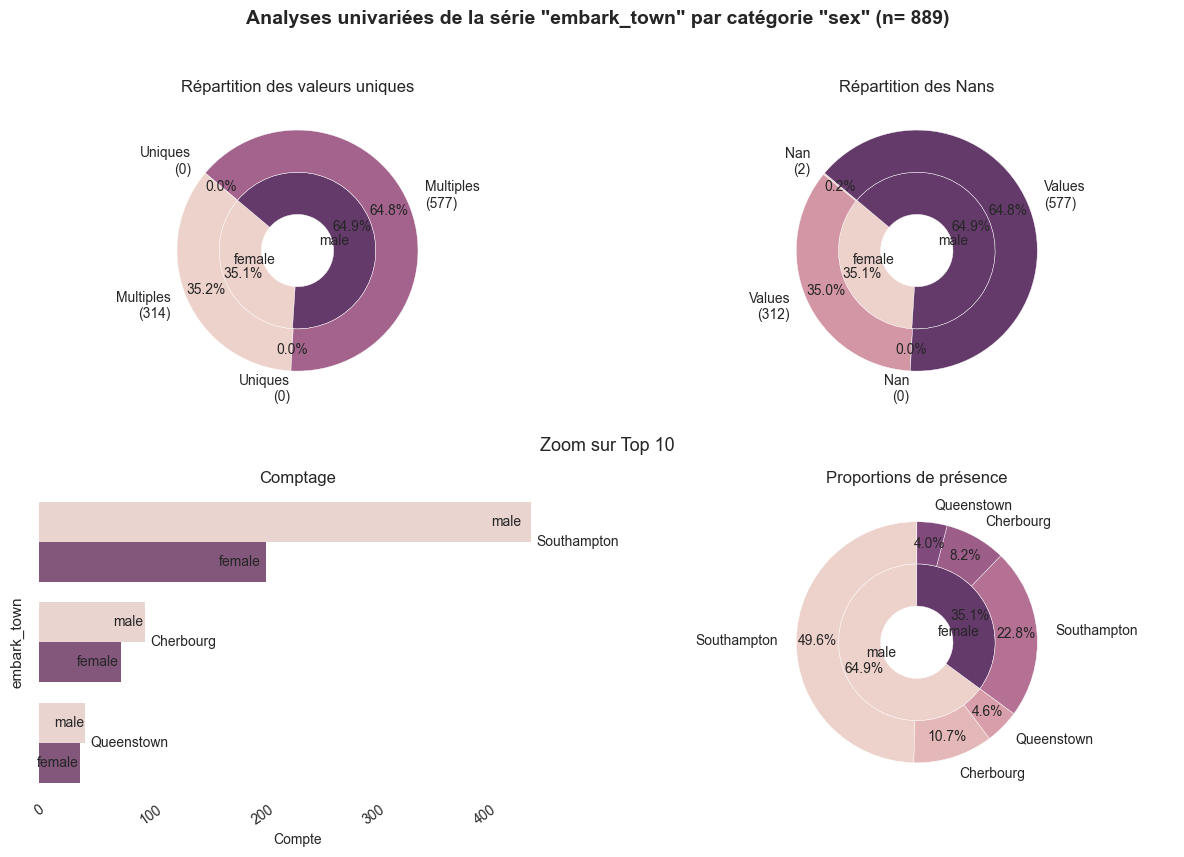
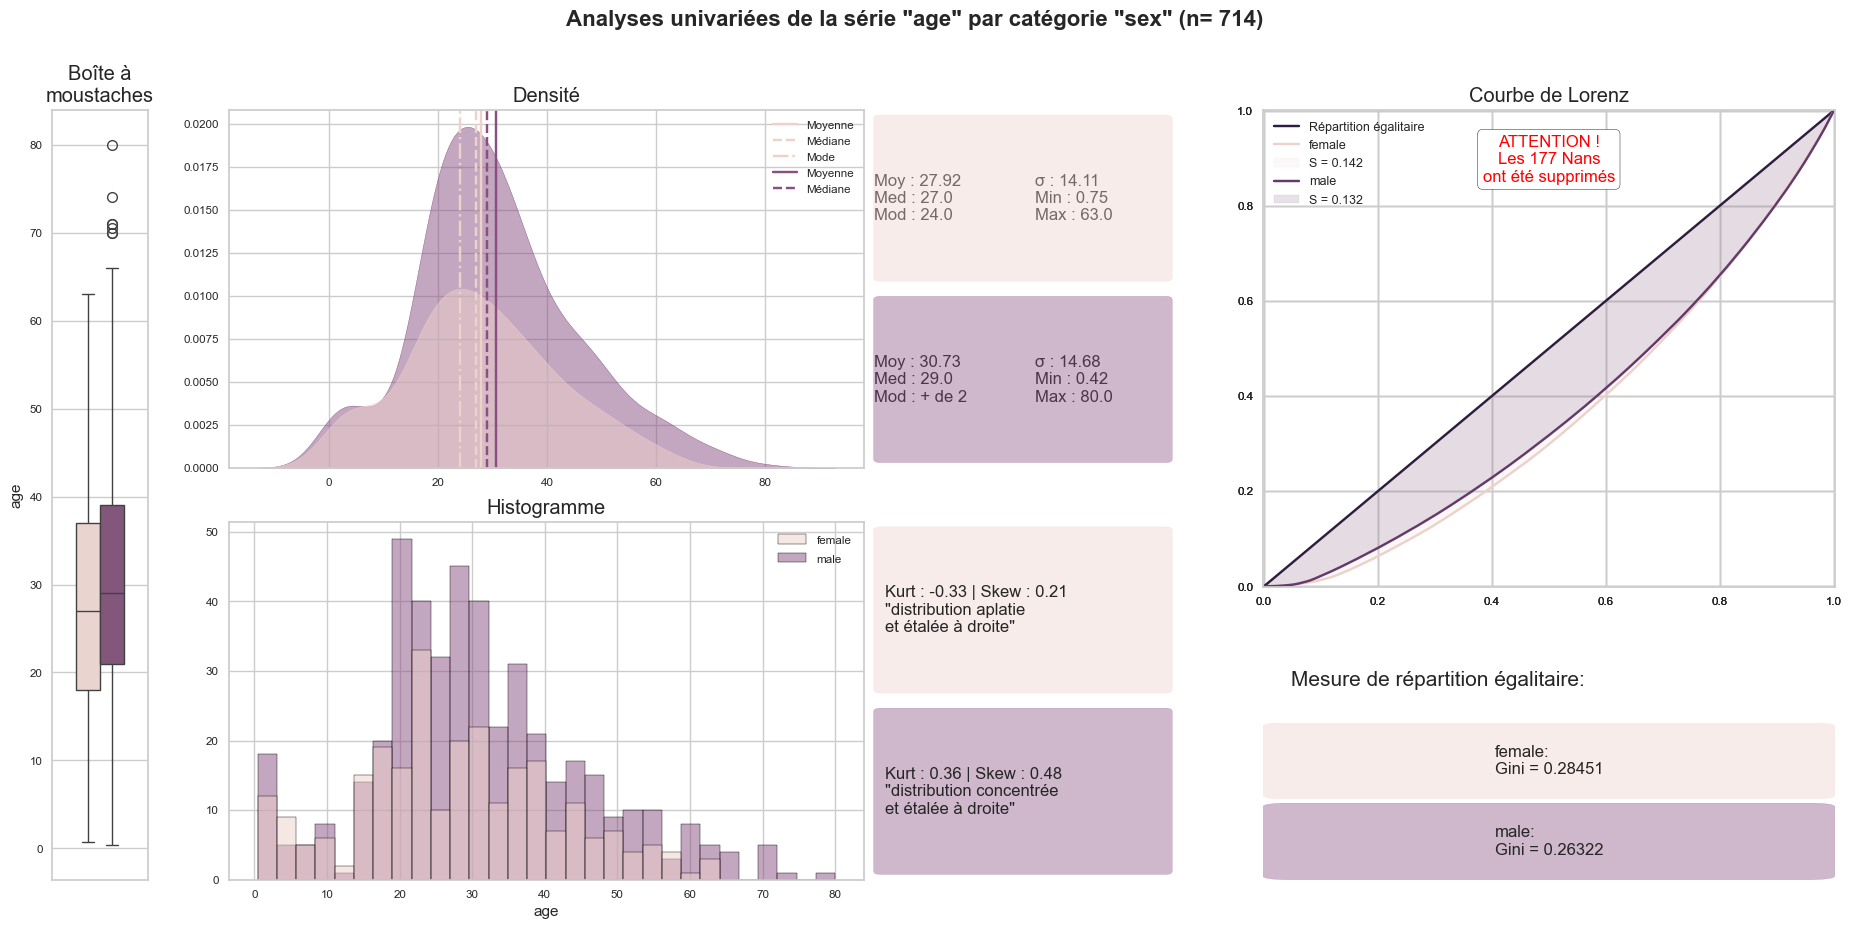

In [2]:
# Création d'une instance de StatUnivariee par catégorie 'sex'
fig = StatUnivariee(df.loc[:, ['age', 'fare', 'embark_town']], hue=df['sex'])
fig

**Méthodes de la classe `StatUnivariee`**
-----------------------------------------

La classe `StatUnivariee` s'utilise principalement au moment de son instanciation. L'objet sera là pour pouvoir ré-afficher La figure ou la sauvegarder dans un fichier HTML:

* `_repr_html_` : méthode qui affiche l'analyse univariée en HTML.   
(Cette méthode est automatiquement appelée dans un Jupiter notebook)


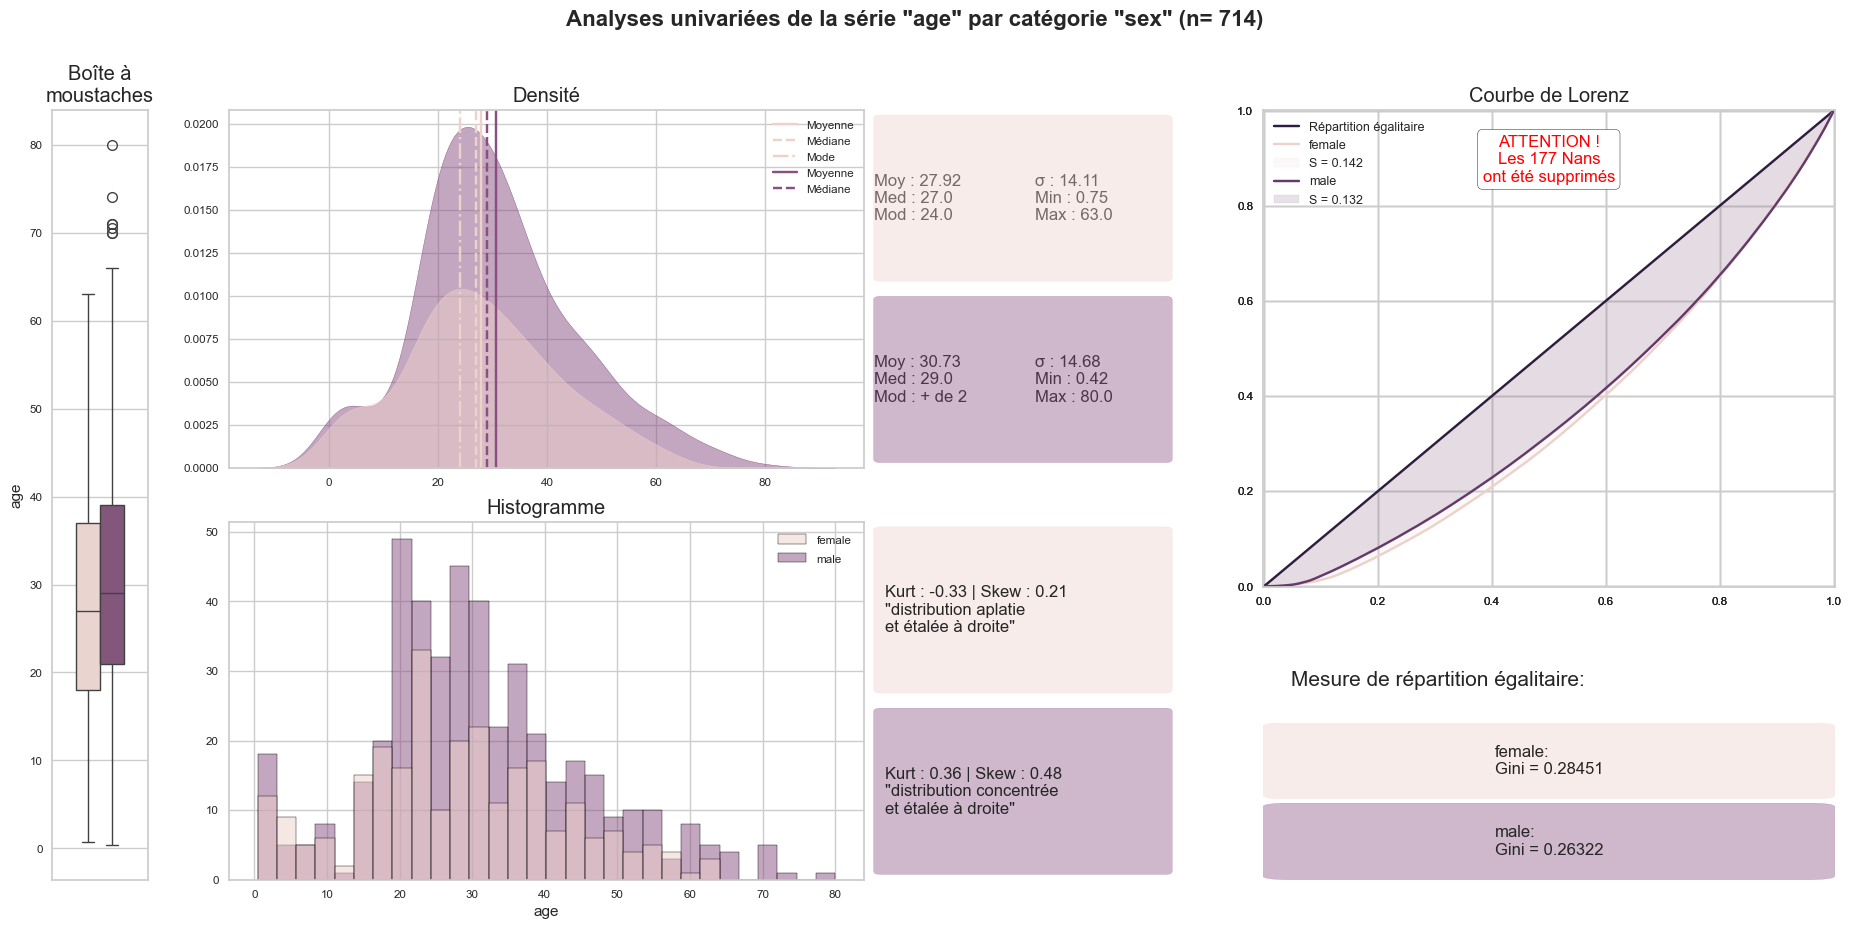
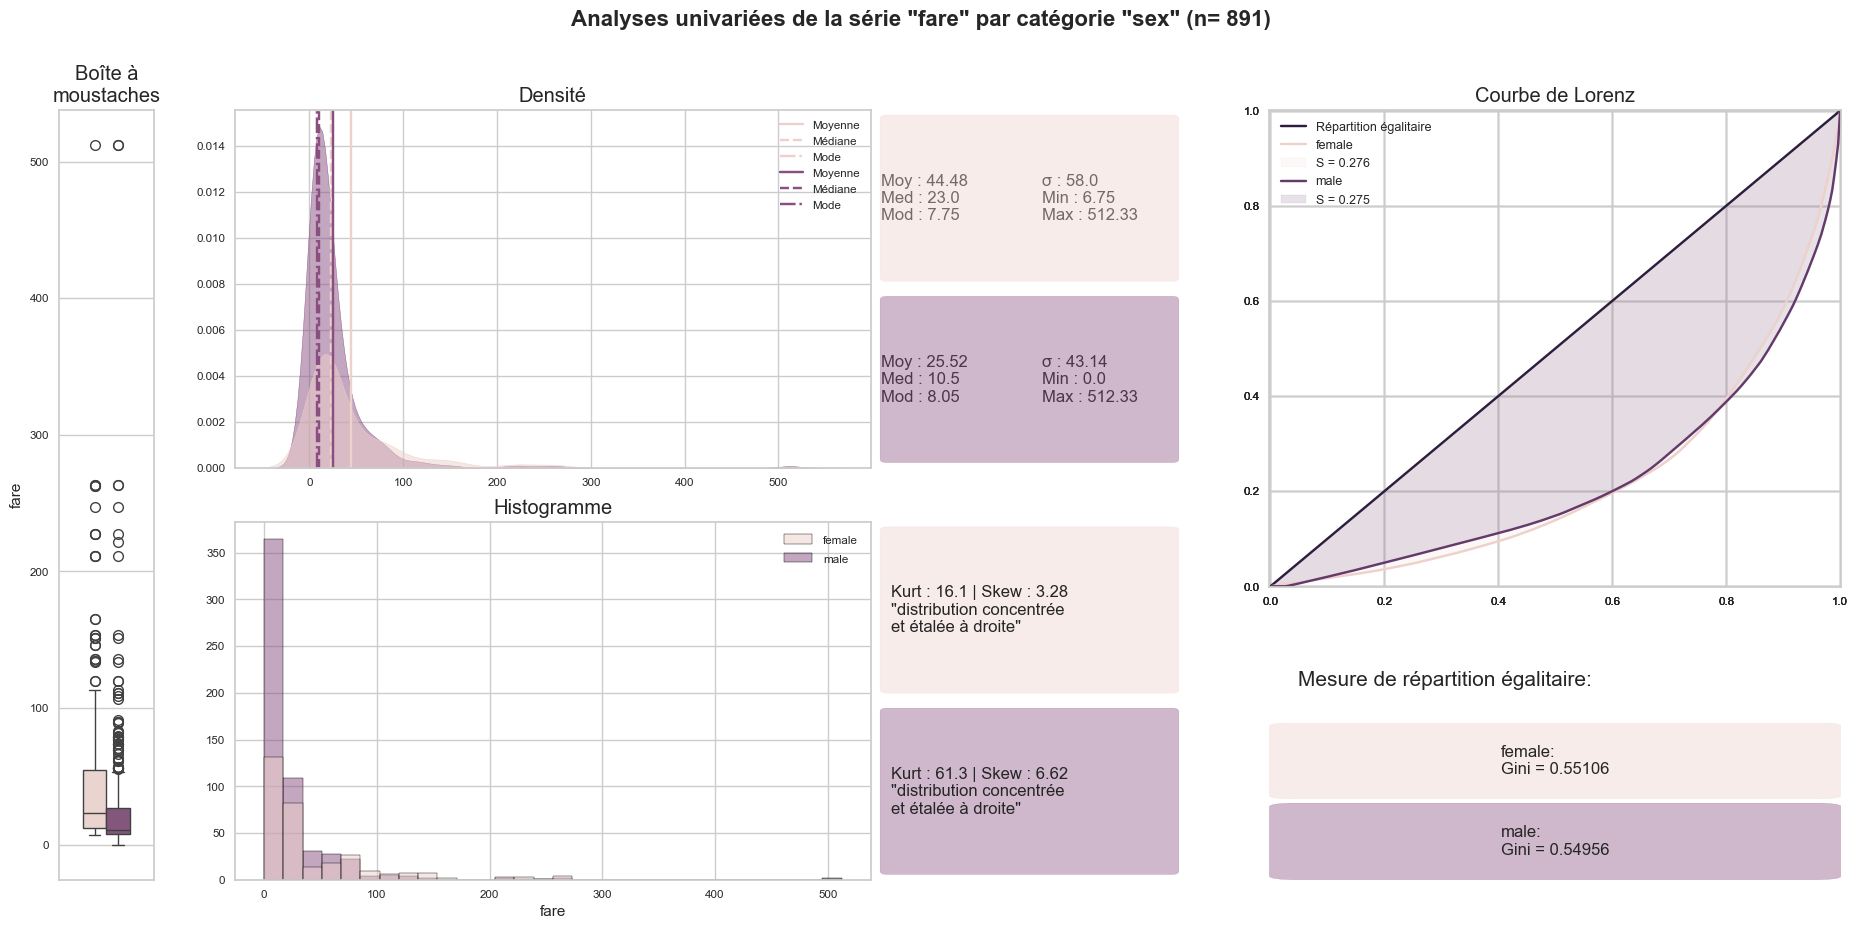
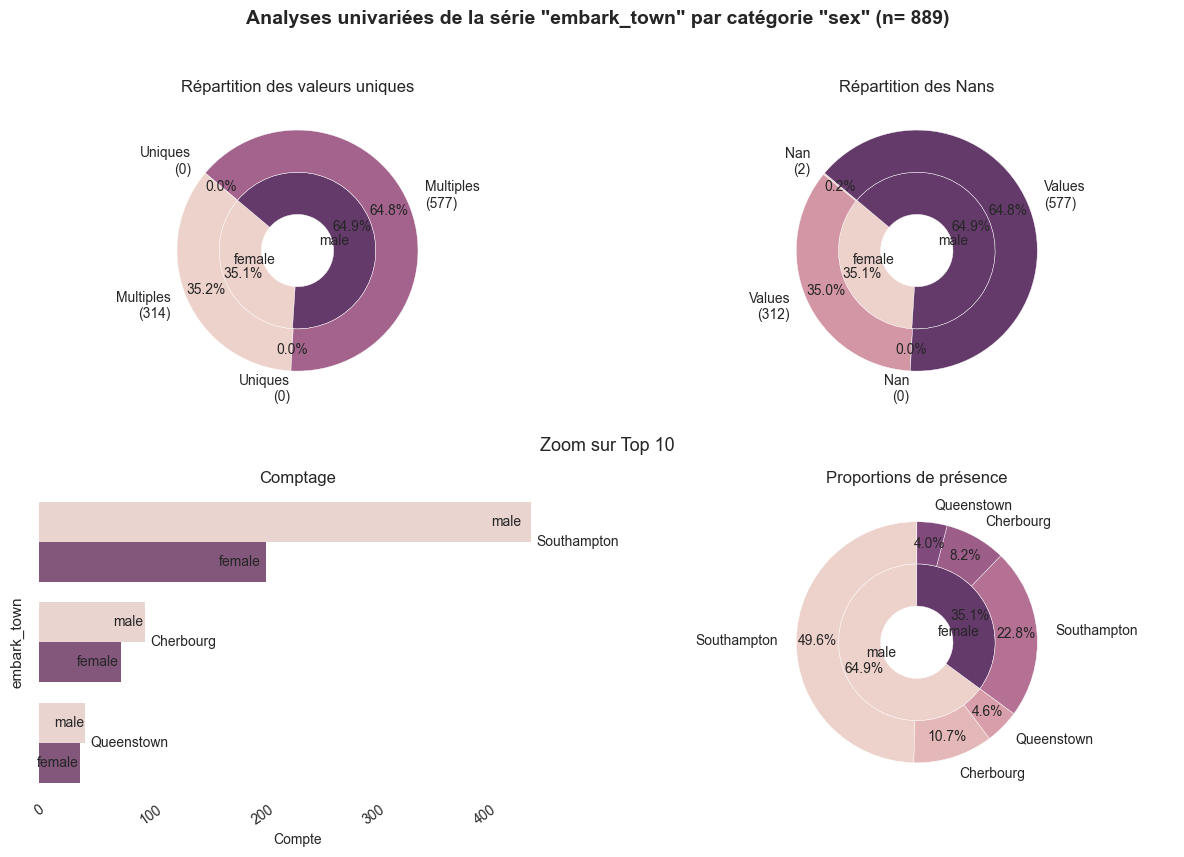
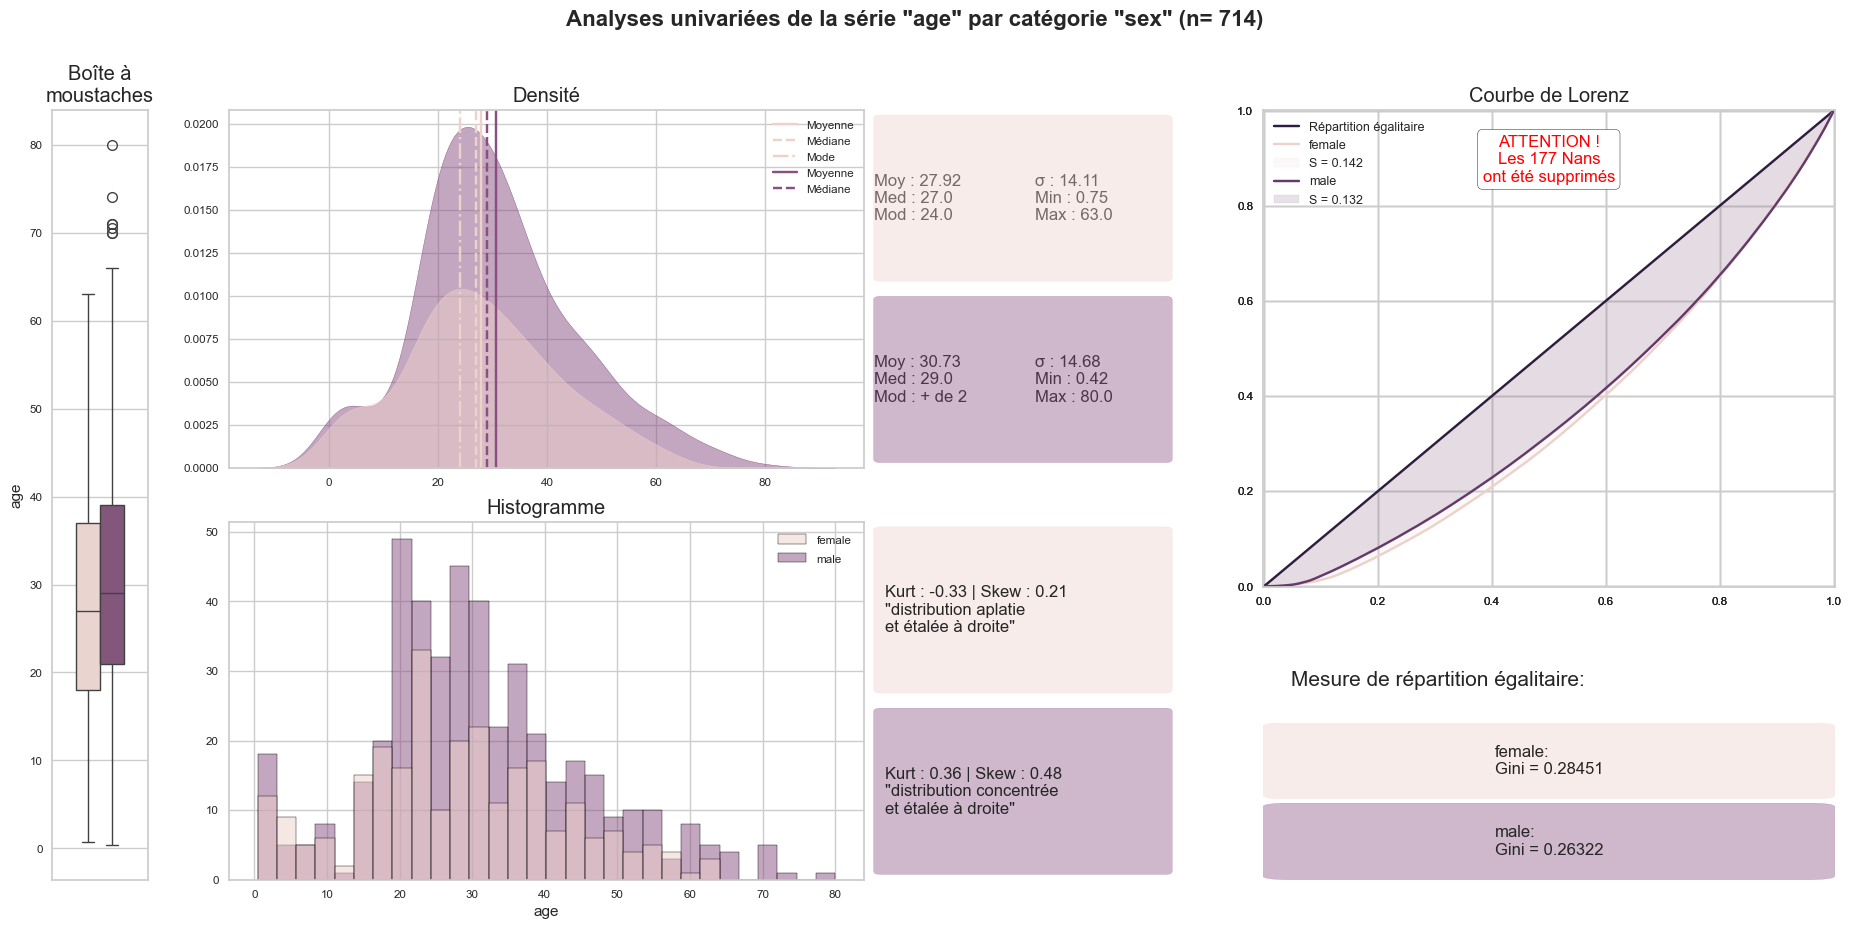

In [3]:
# Affichage de la figure via la méthode _repr_html_()
fig

In [4]:
# Sauvegarde de la figure sous un fichier HTML
fig.save_html()

**Personnalisation de l'analyse univariée**
-----------------------------------------

La classe `StatUnivariee` offre plusieurs paramètres pour personnaliser l'analyse univariée :

* `hist_bins` : paramètre qui définit le nombre de séparateurs sur l'histogramme.
* `lorenz` : paramètre qui définit si la courbe de Lorenz est affichée ou non.
* `lorenz_x(y)ticks` : Paramètres qui rajoutent des lignes de marquage sur les axes X ou y permettant de mettre en avant des valeurs importantes.
* `figsize` : paramètre qui définit la taille de la figure.
* `text_frontsize` : paramètre qui définit la taille de la police.
* `stat_centrales_lines` : paramètre qui définit si les lignes de stats de tendances sont affichées ou non.

In [5]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')


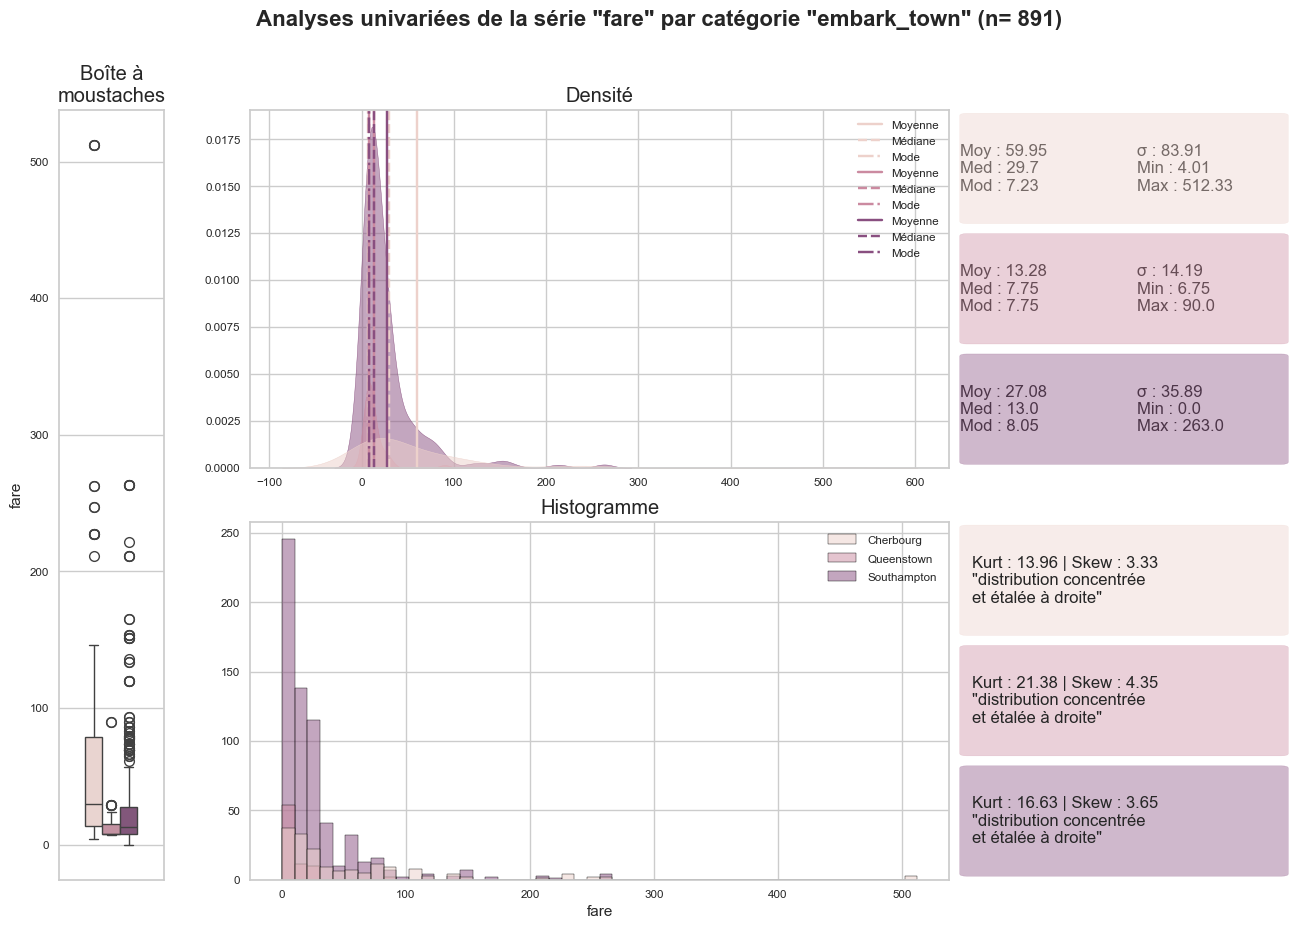
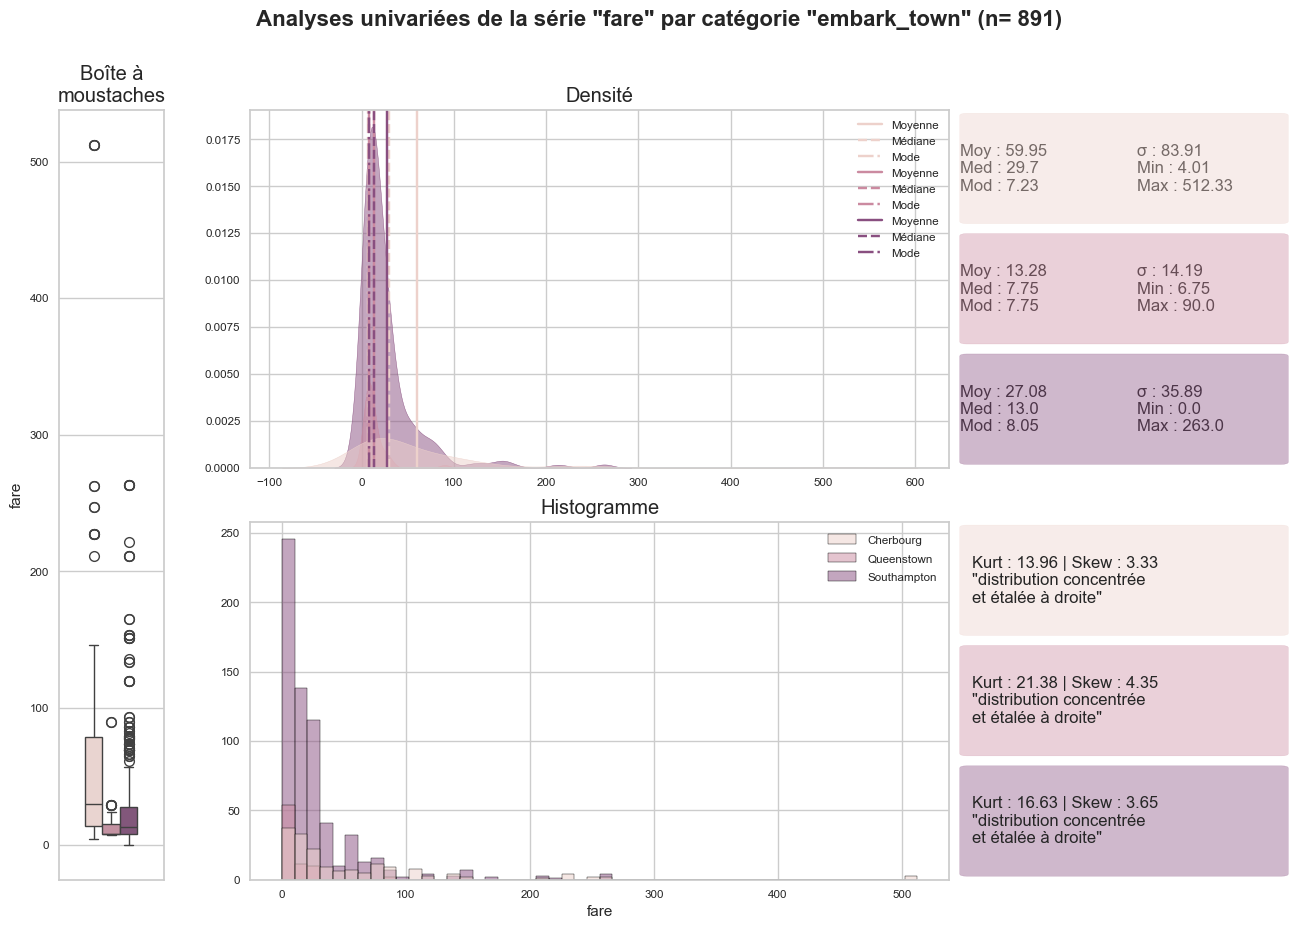

In [6]:
# Exemple de personnalisation de l'analyse univariée
stat = StatUnivariee(df['fare'], hue=df['embark_town'], hist_bins=50, lorenz=False)
stat

**Démo**
--------------

100%|██████████| 15/15 [00:07<00:00,  1.97series/s]



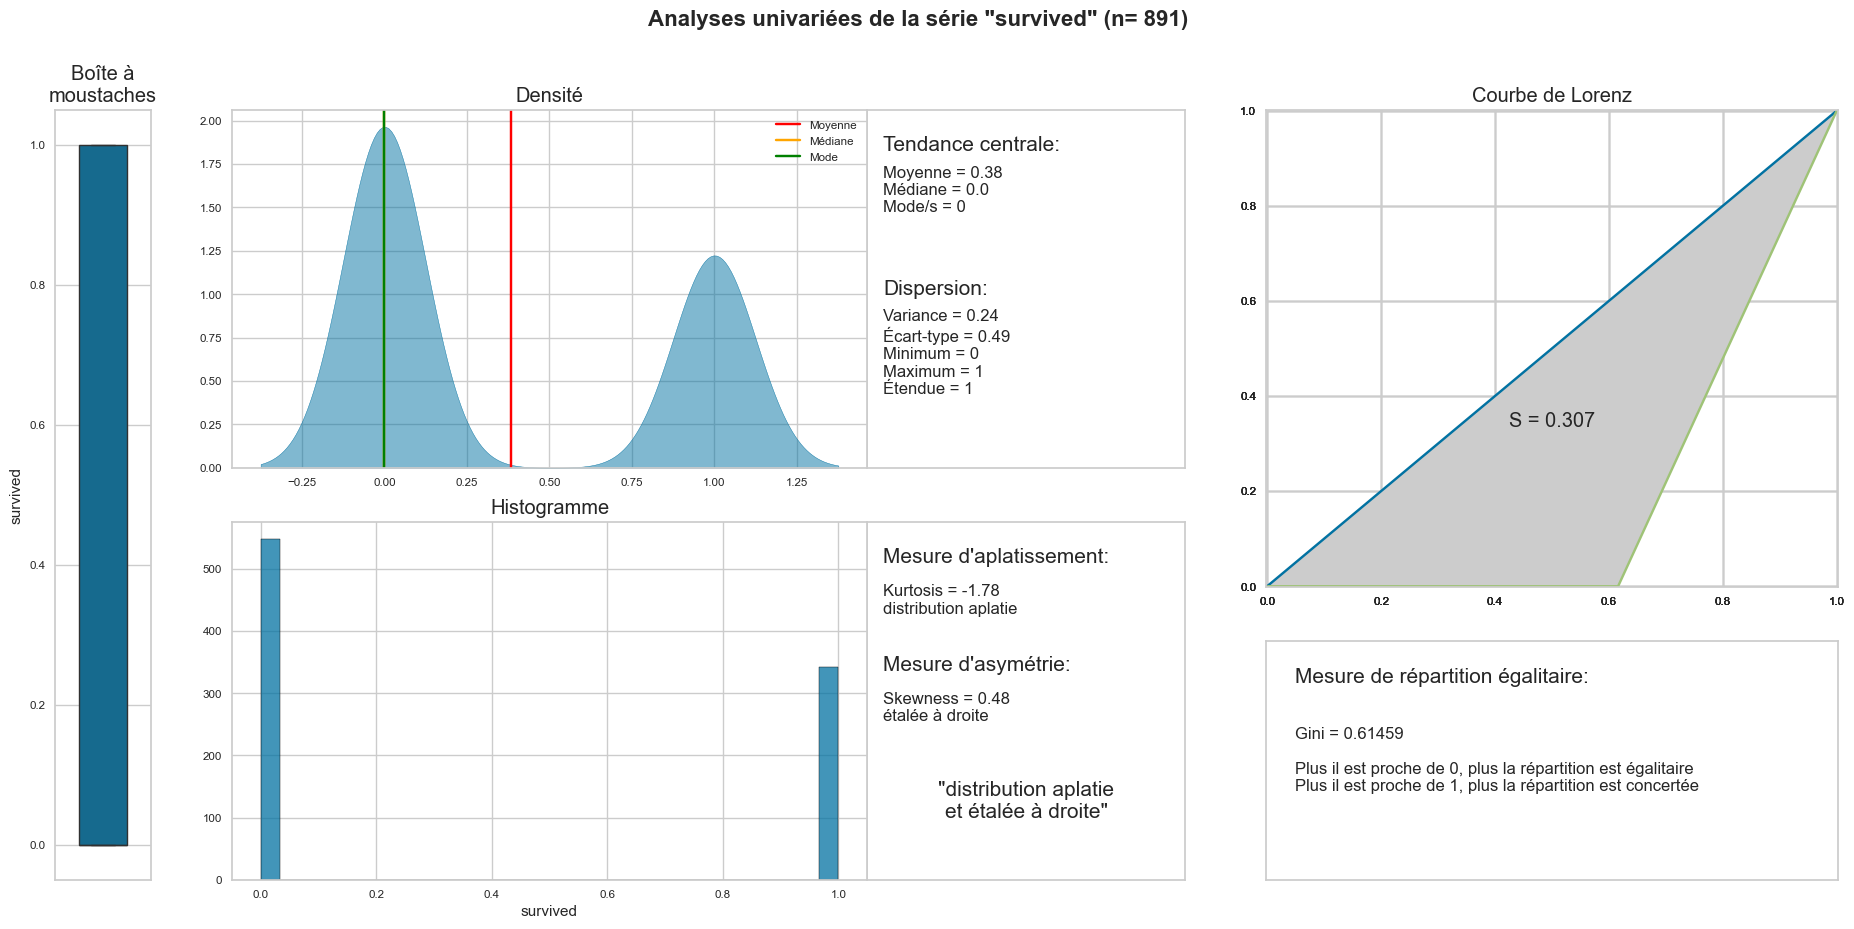
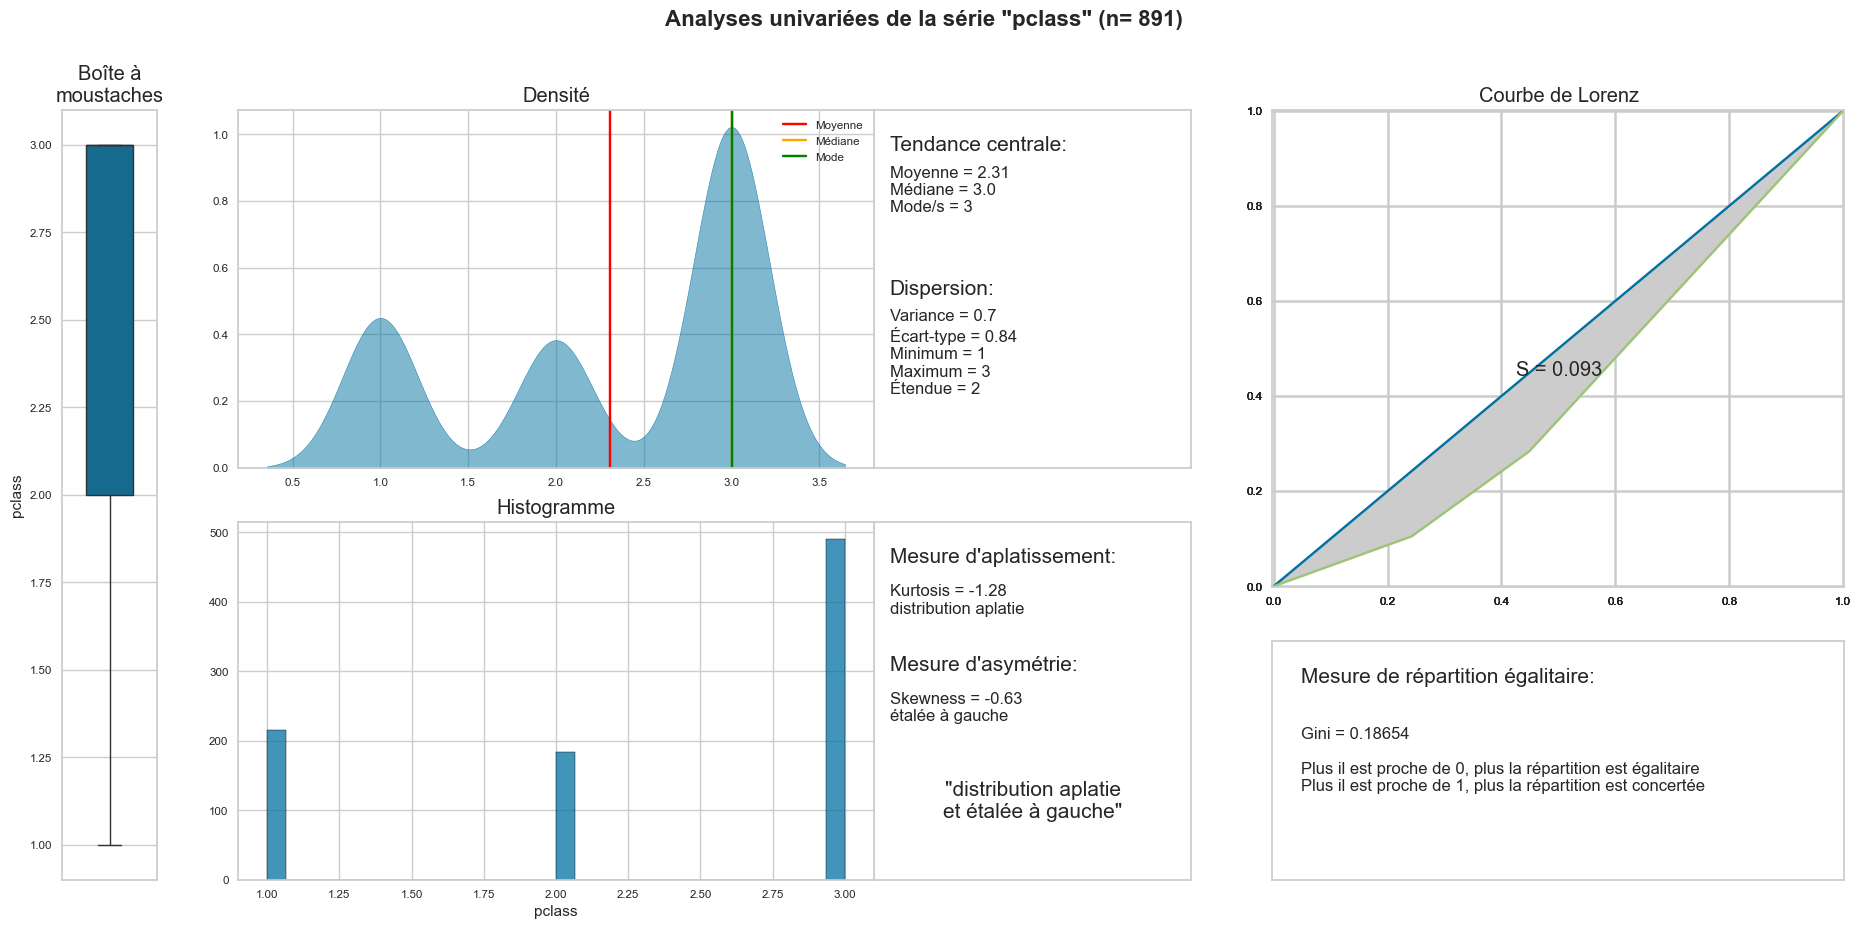
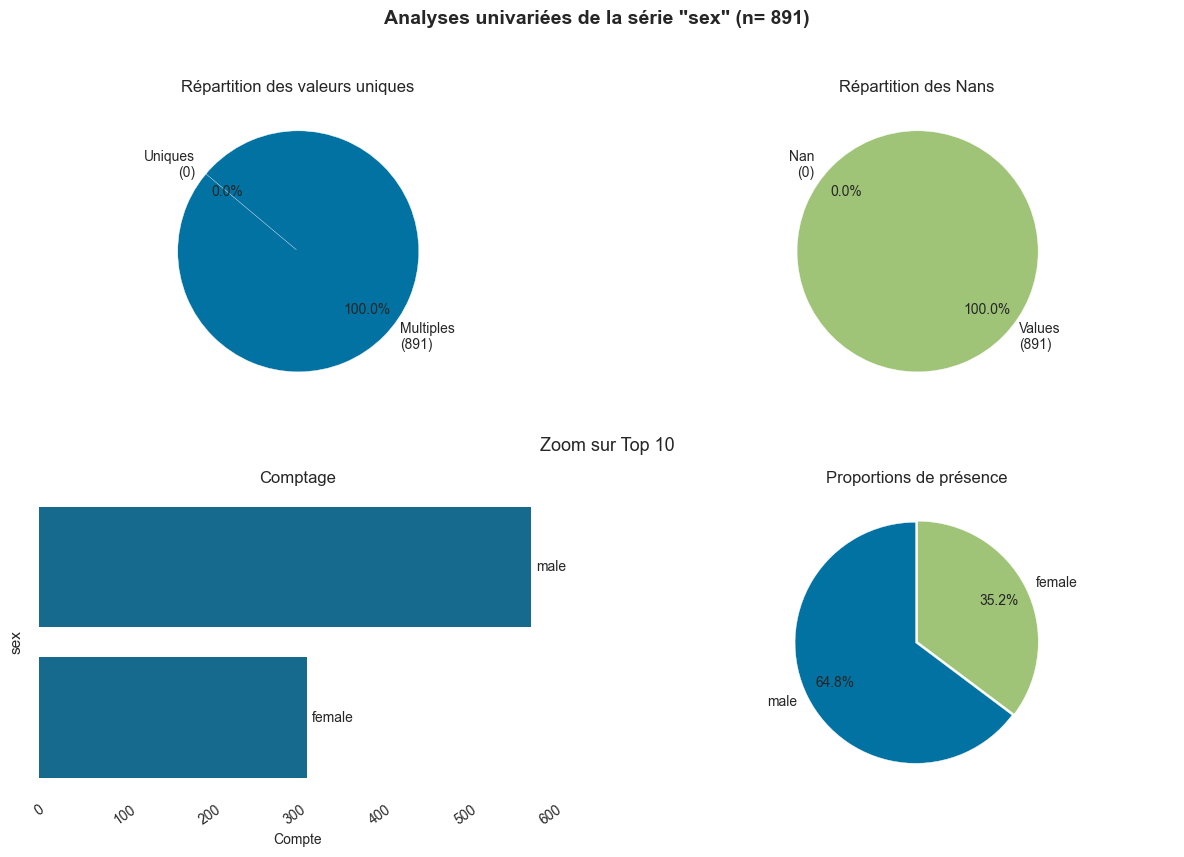
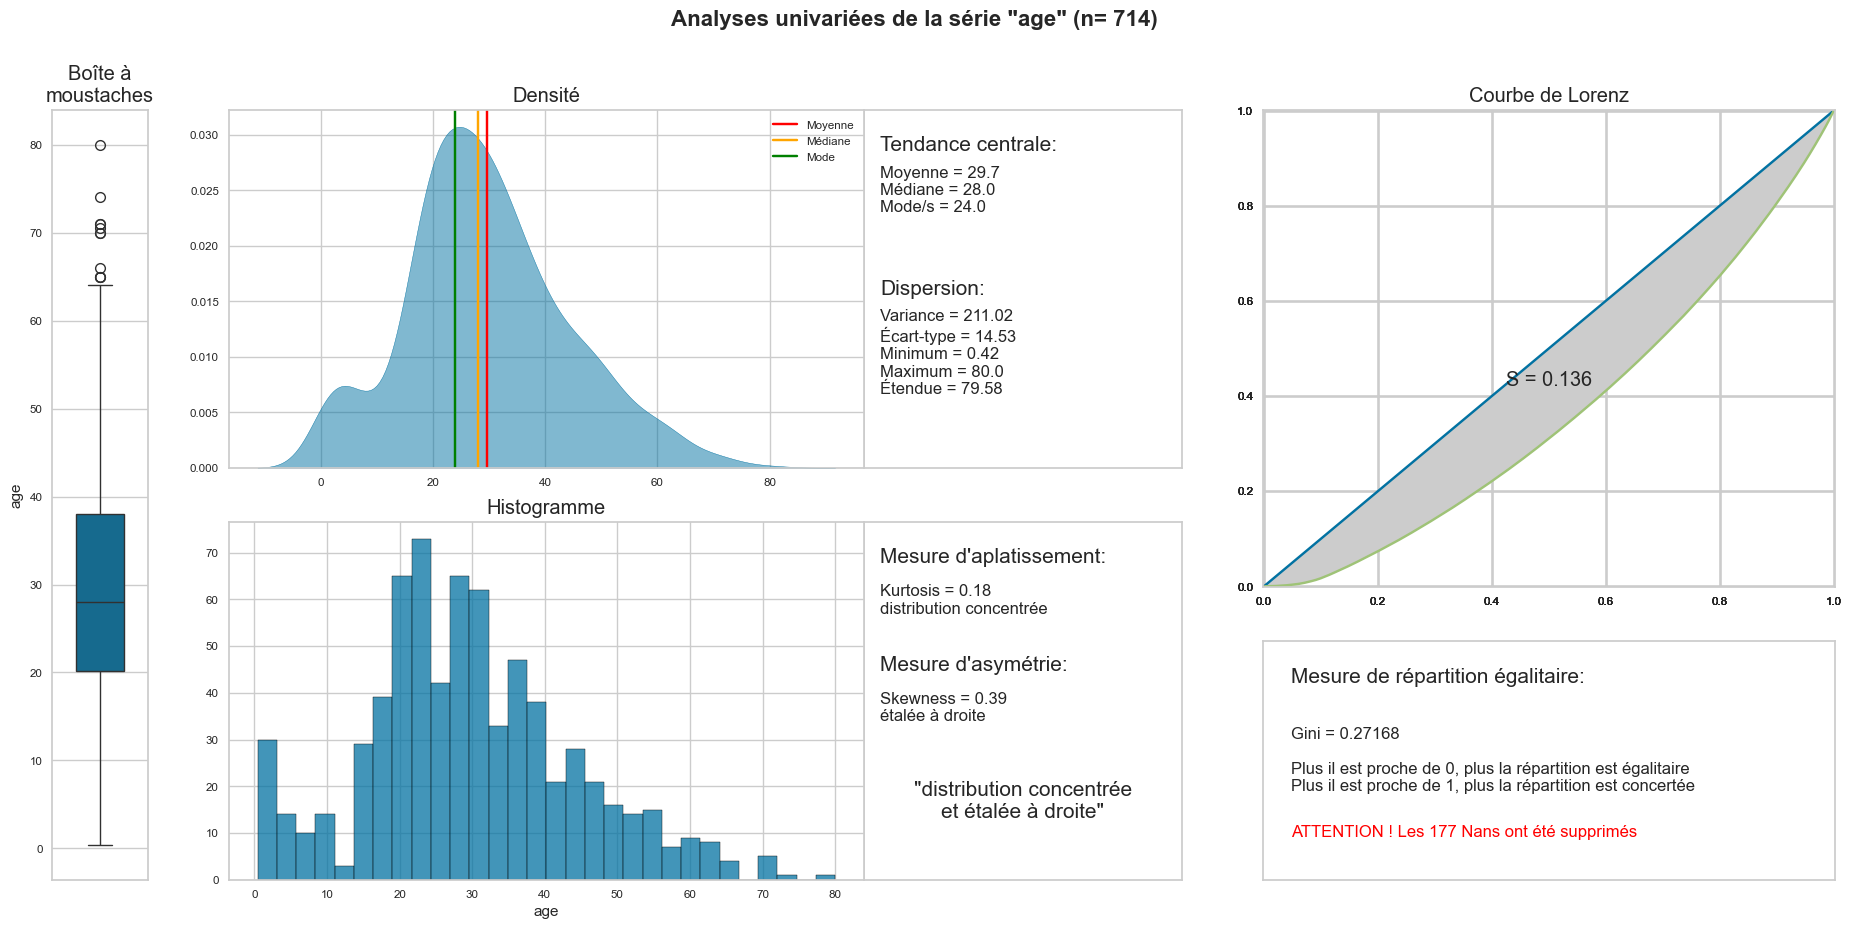
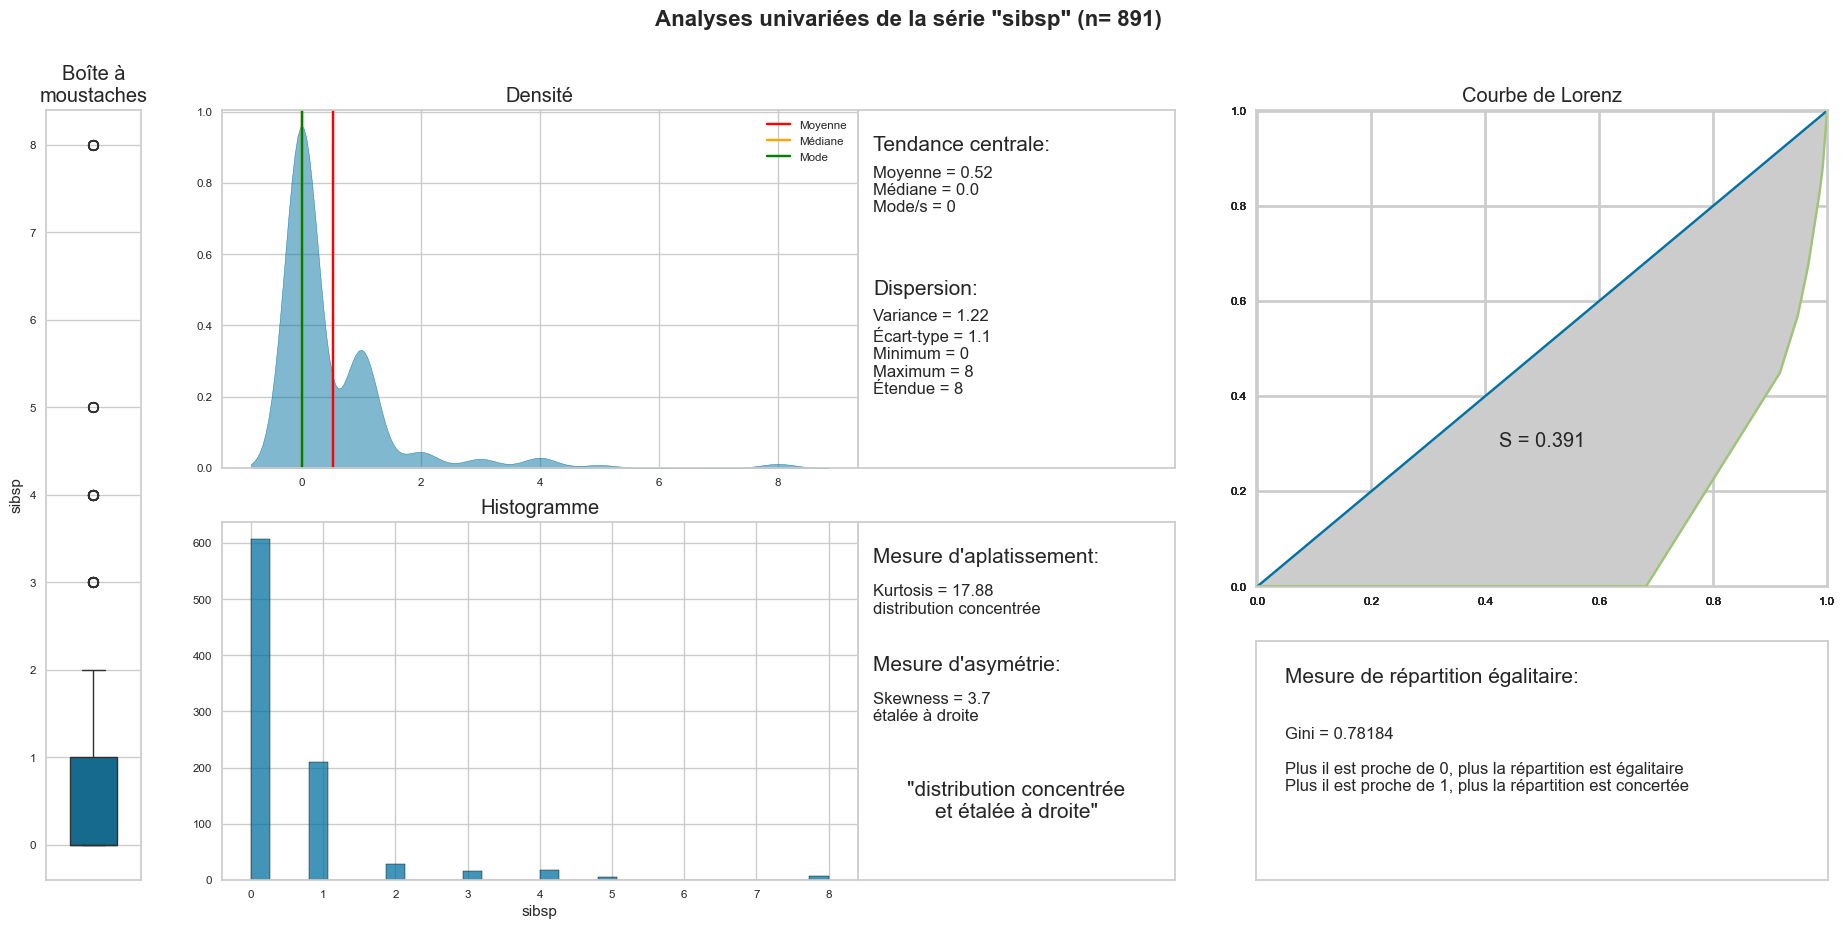
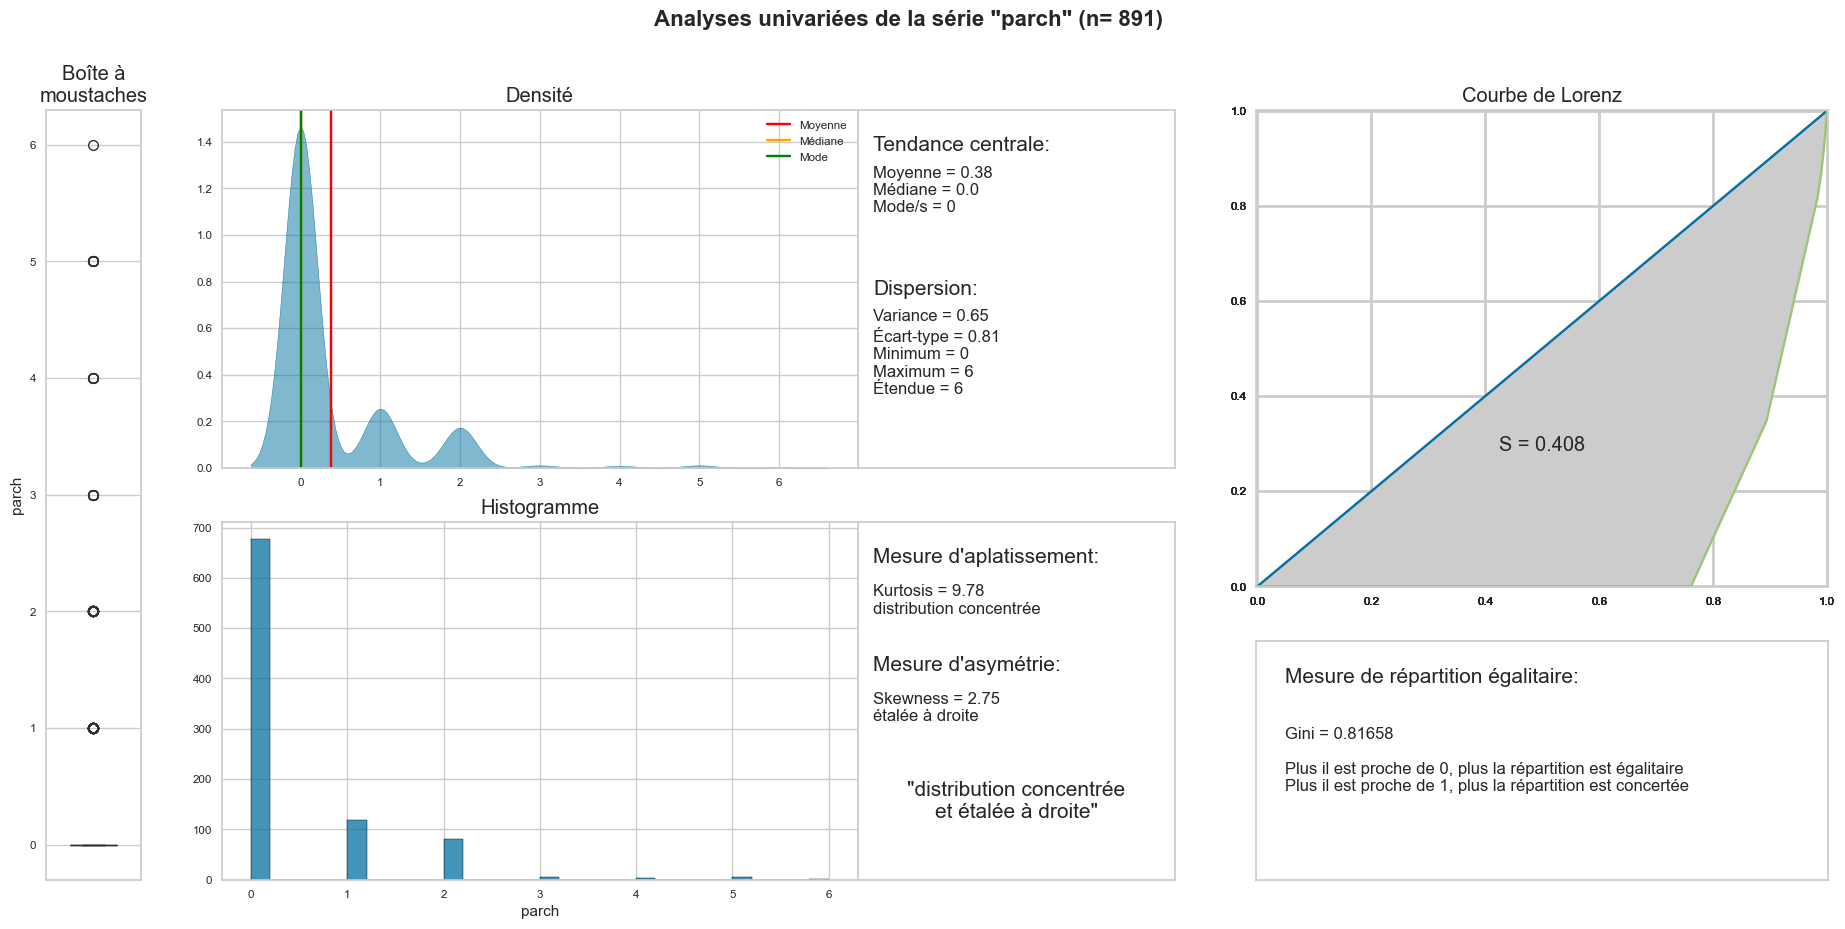
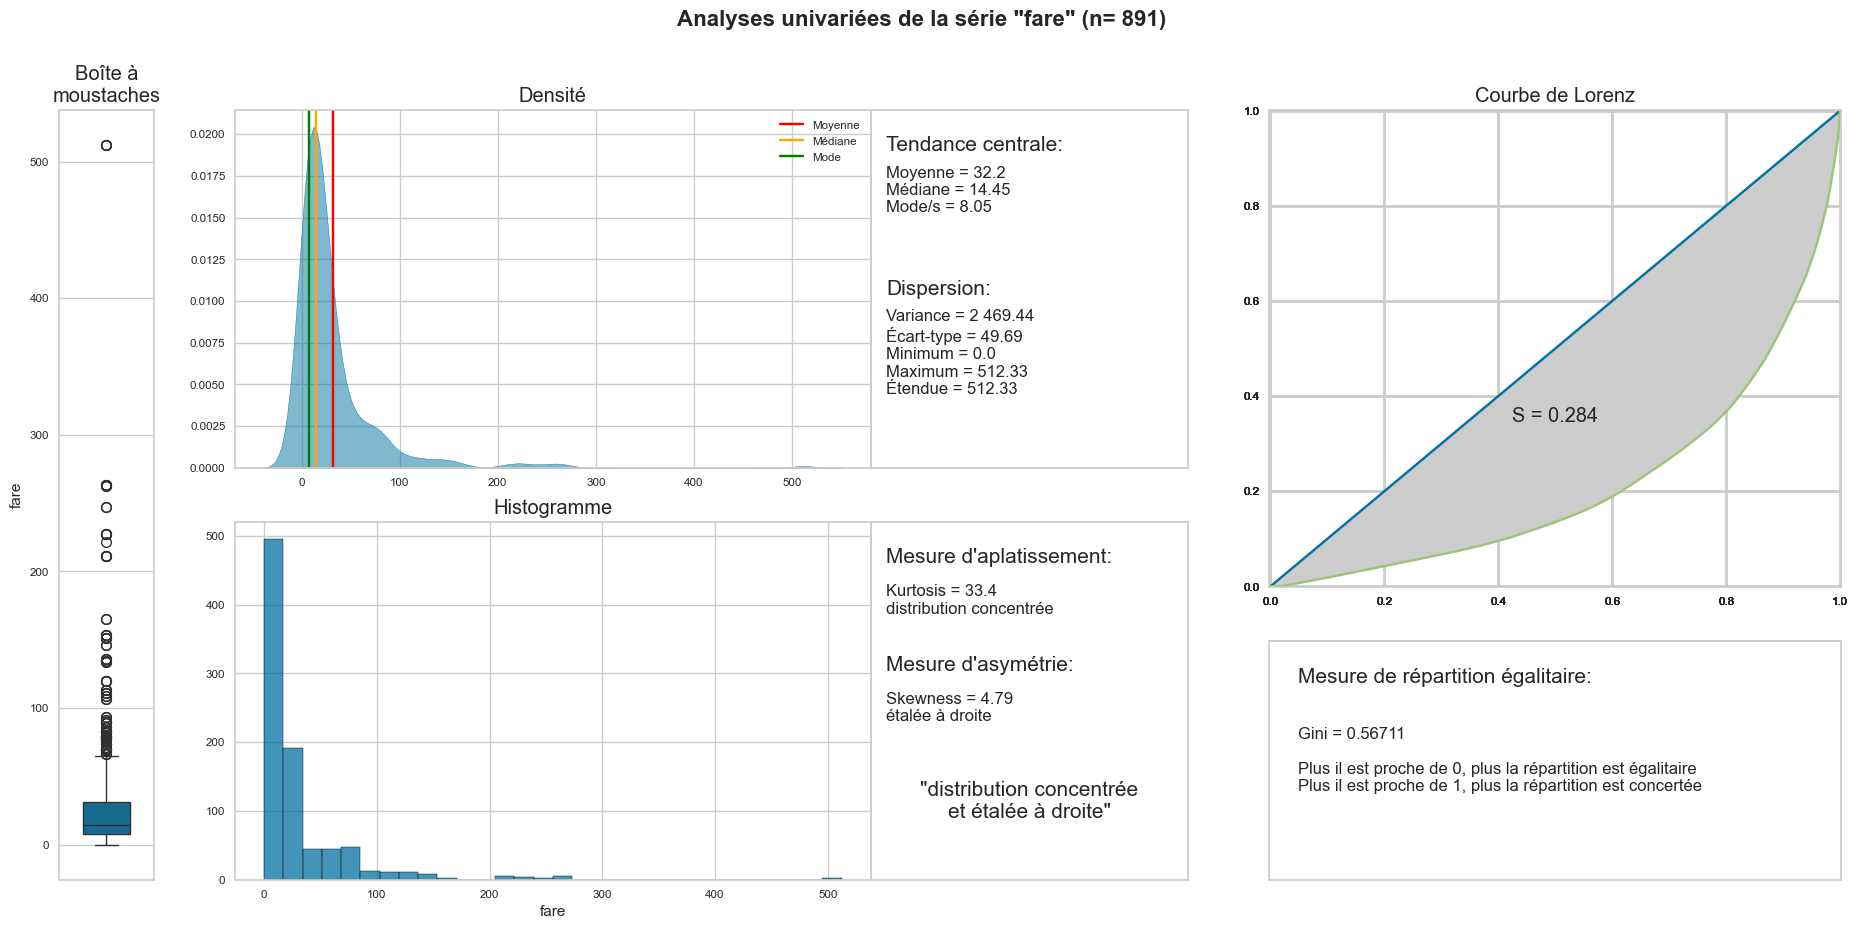
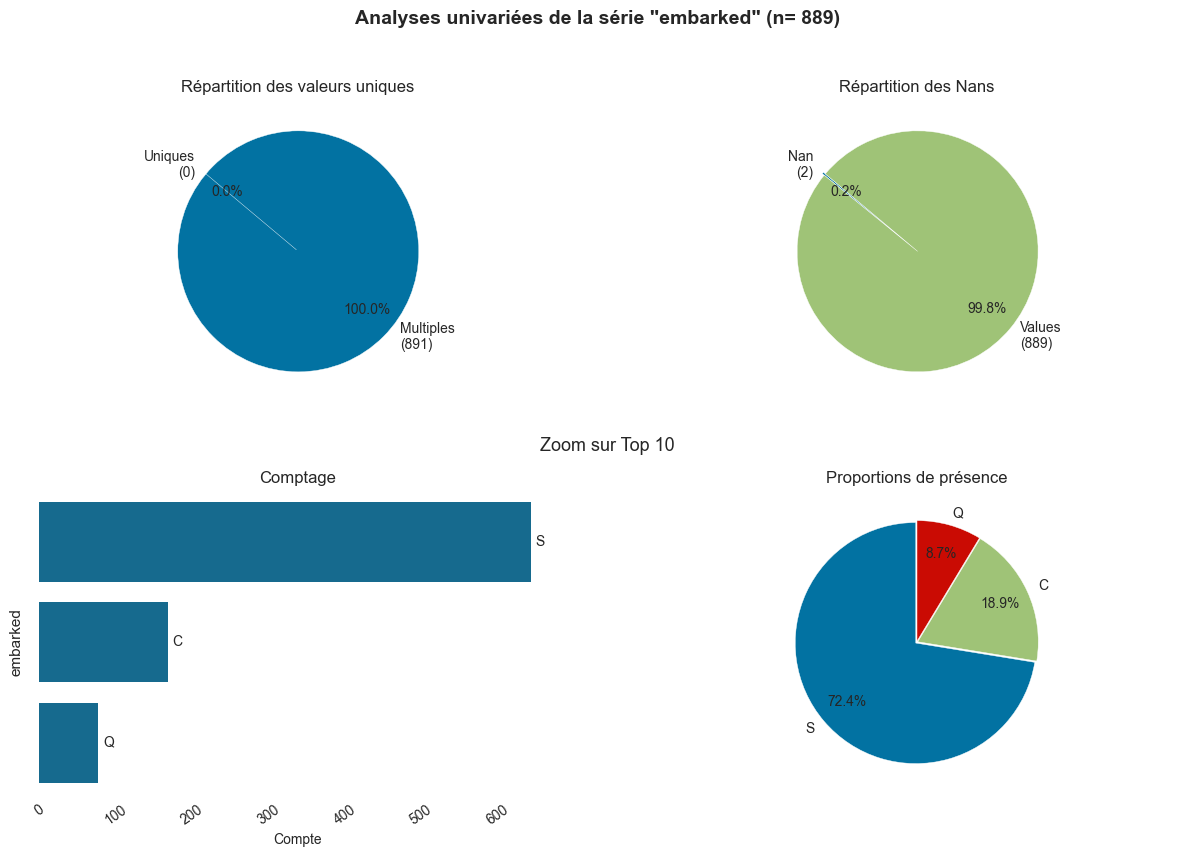
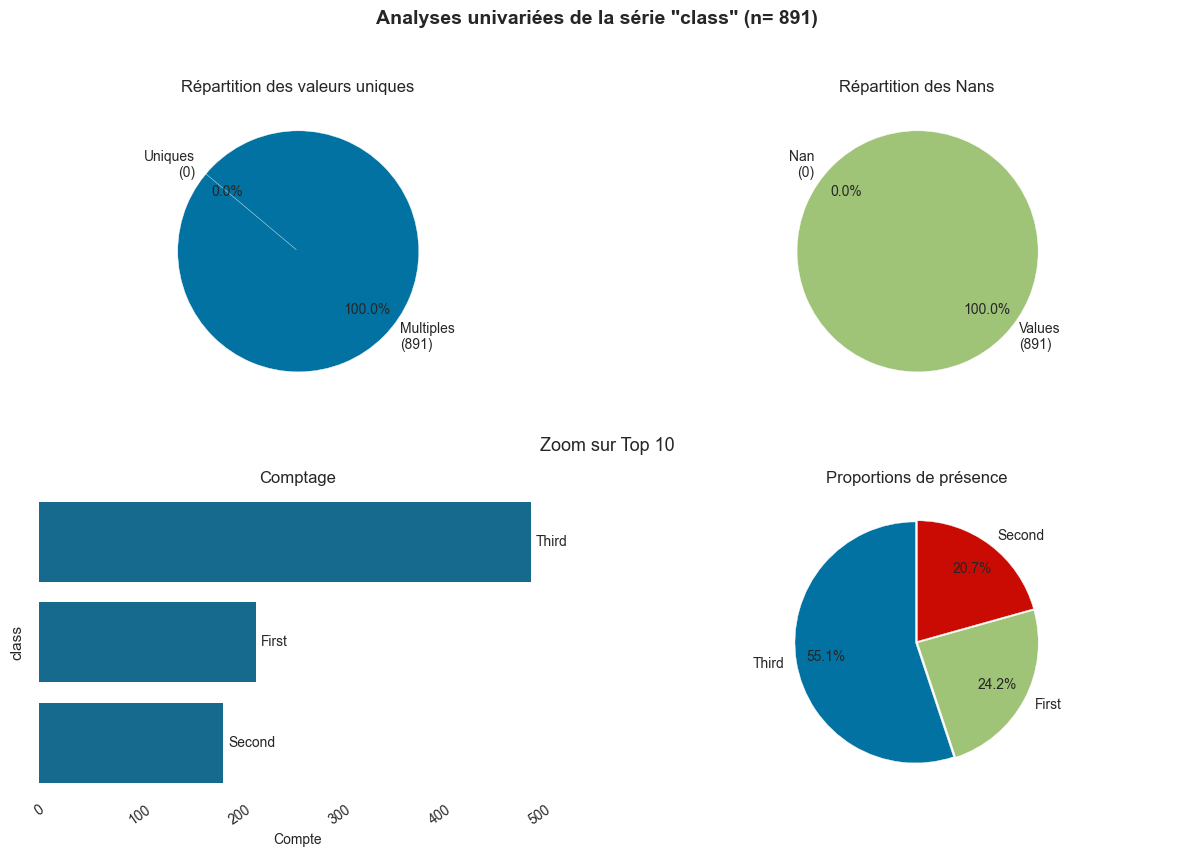
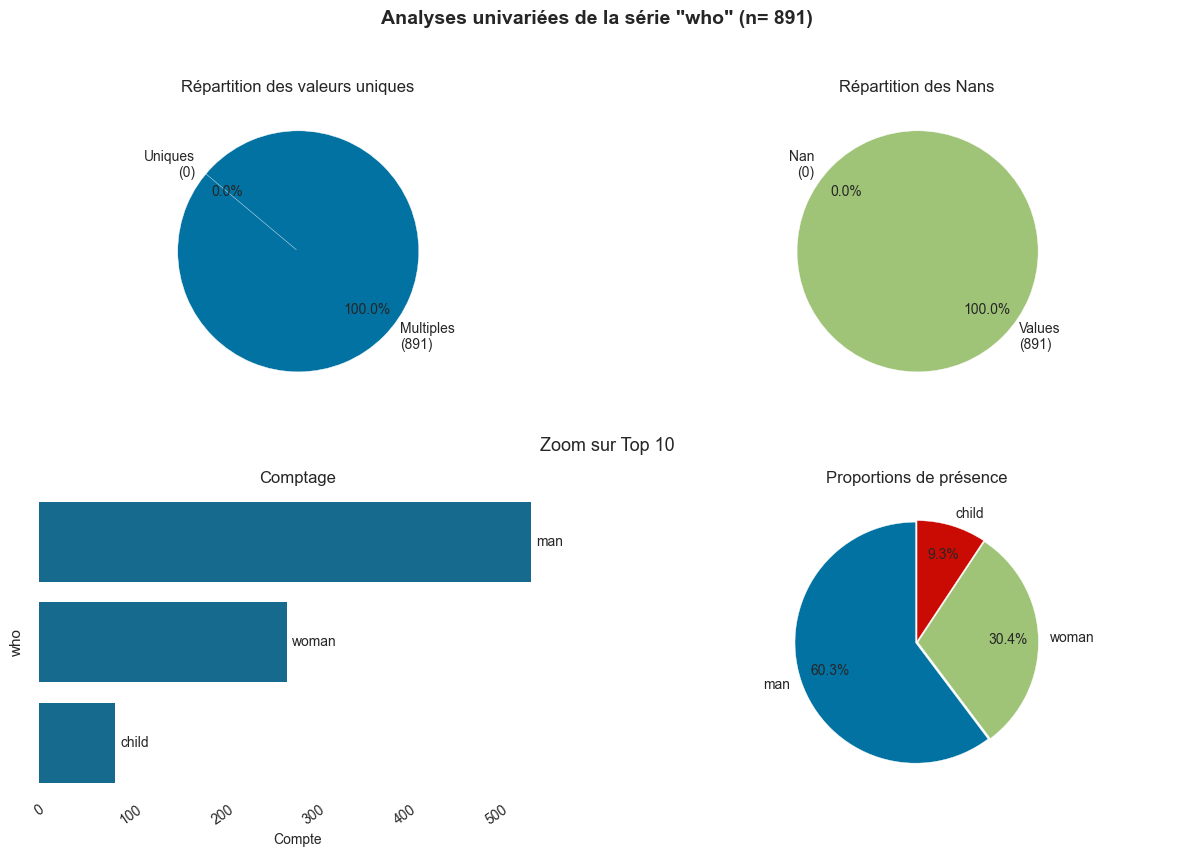
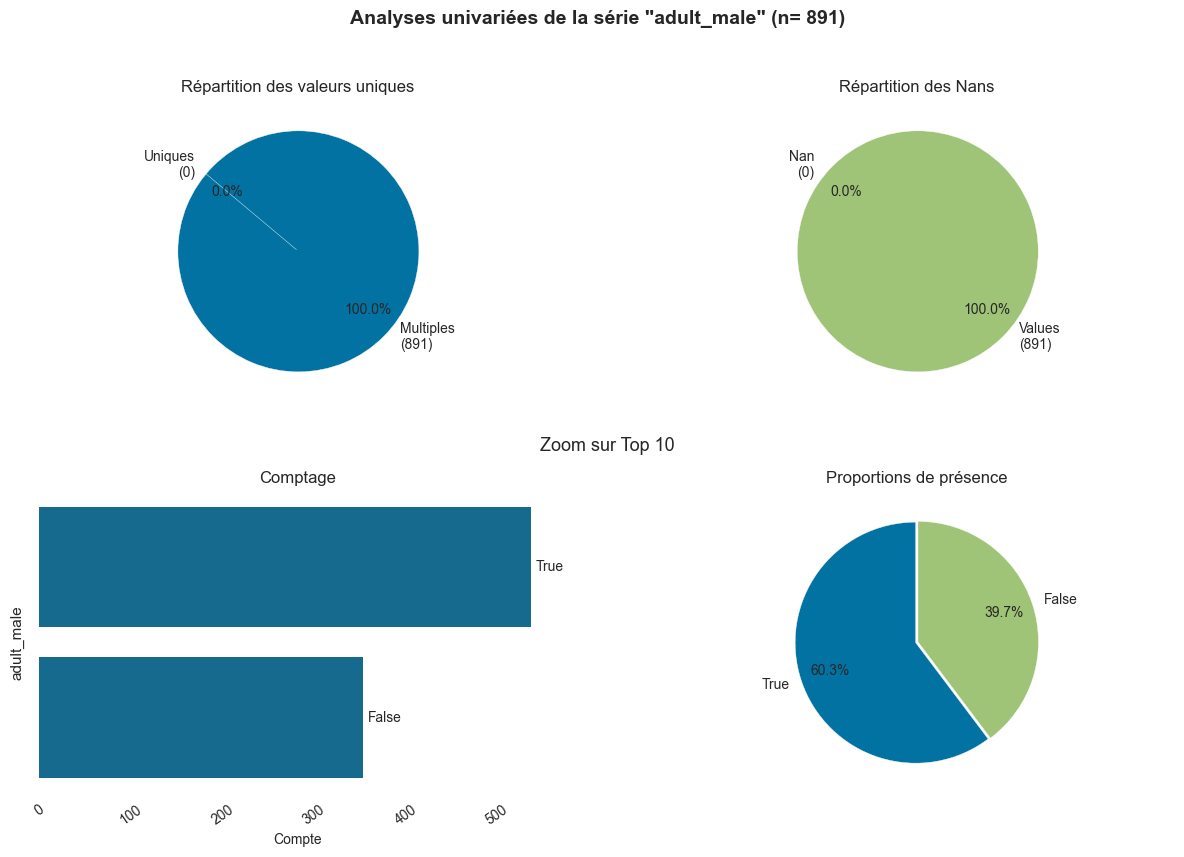
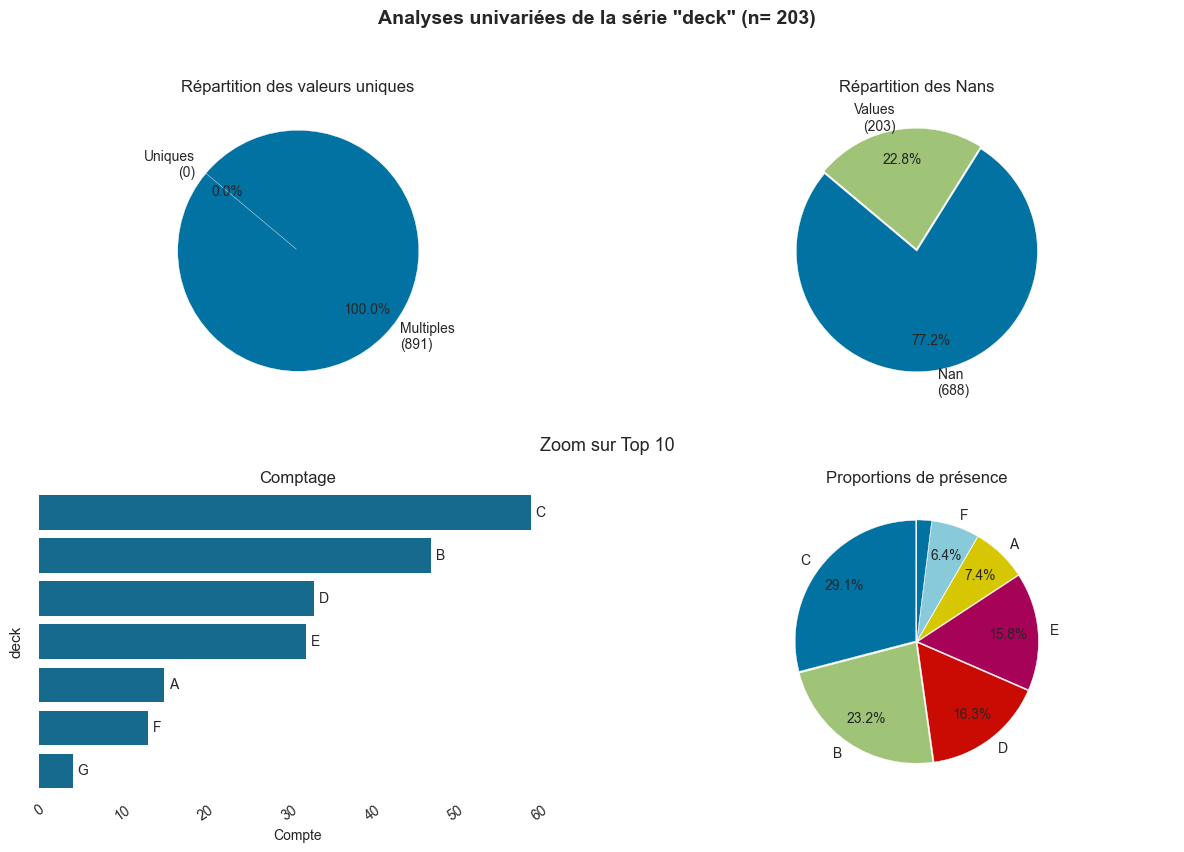
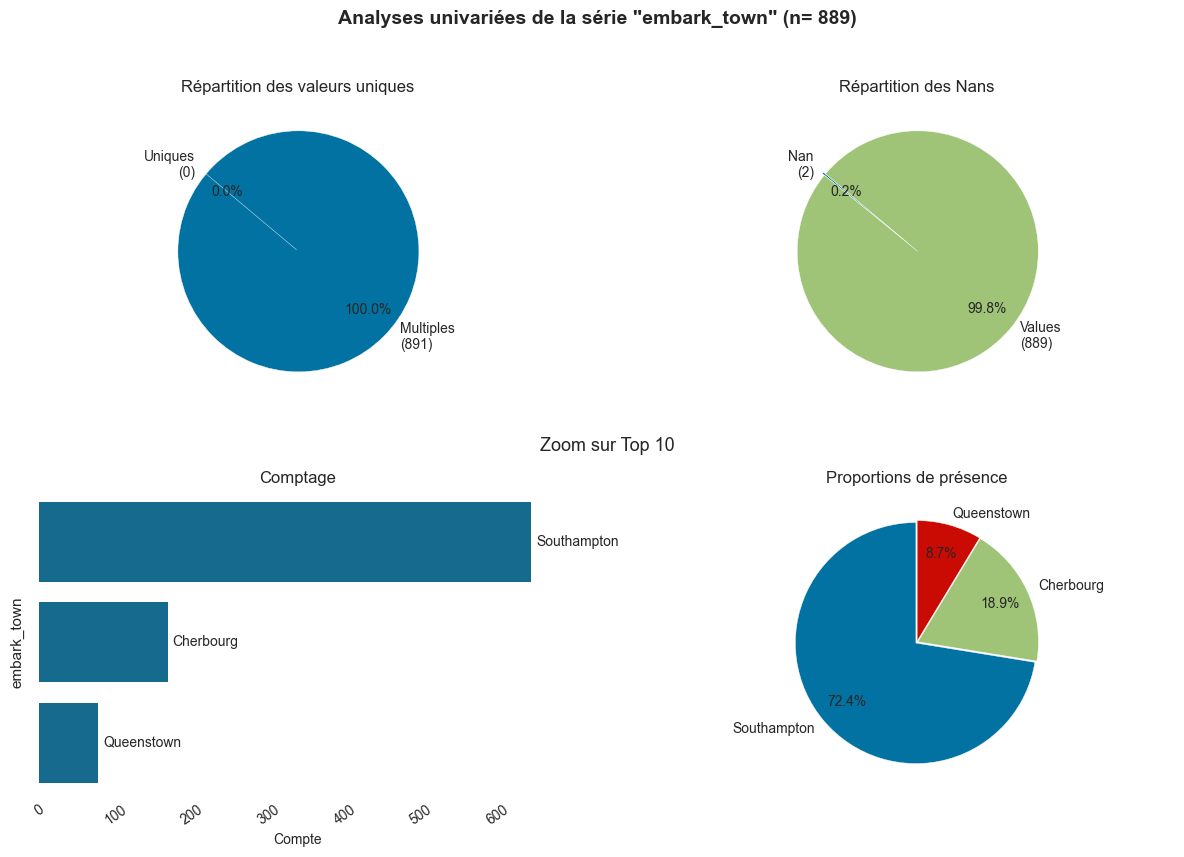
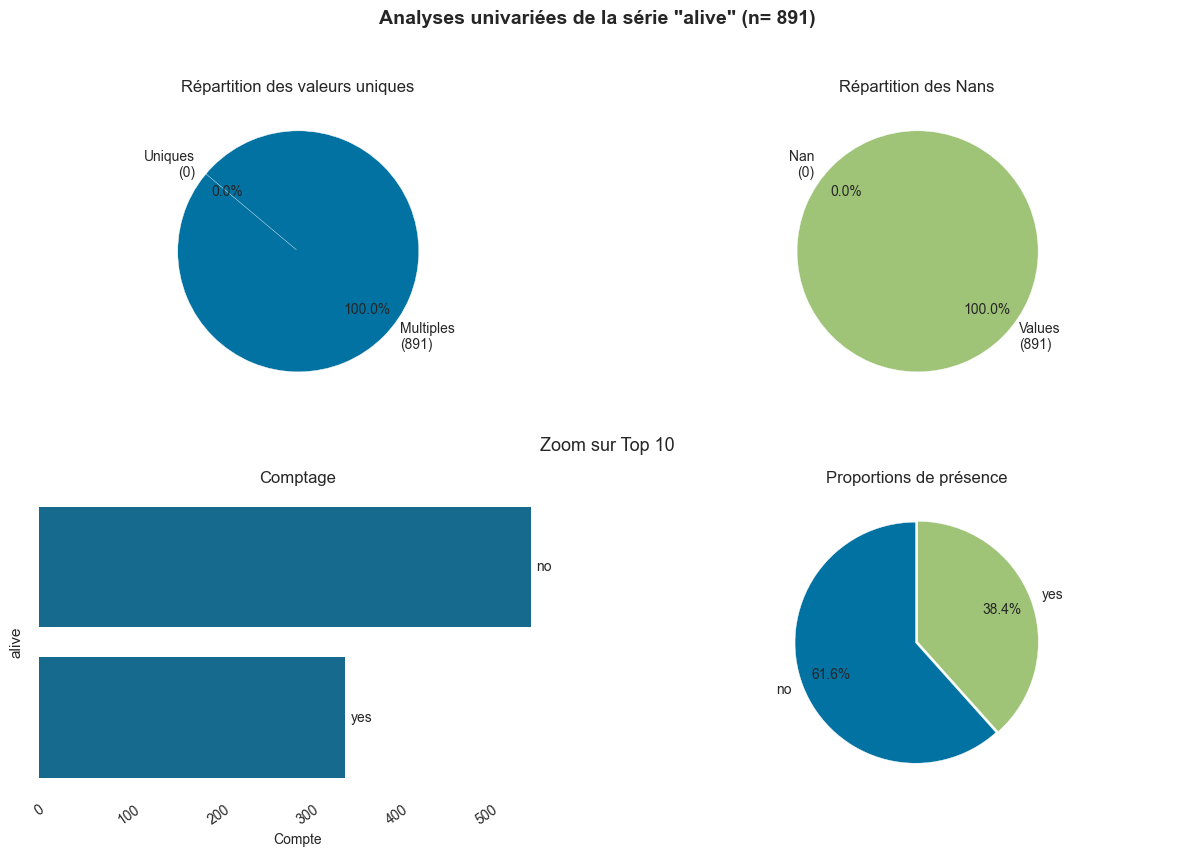
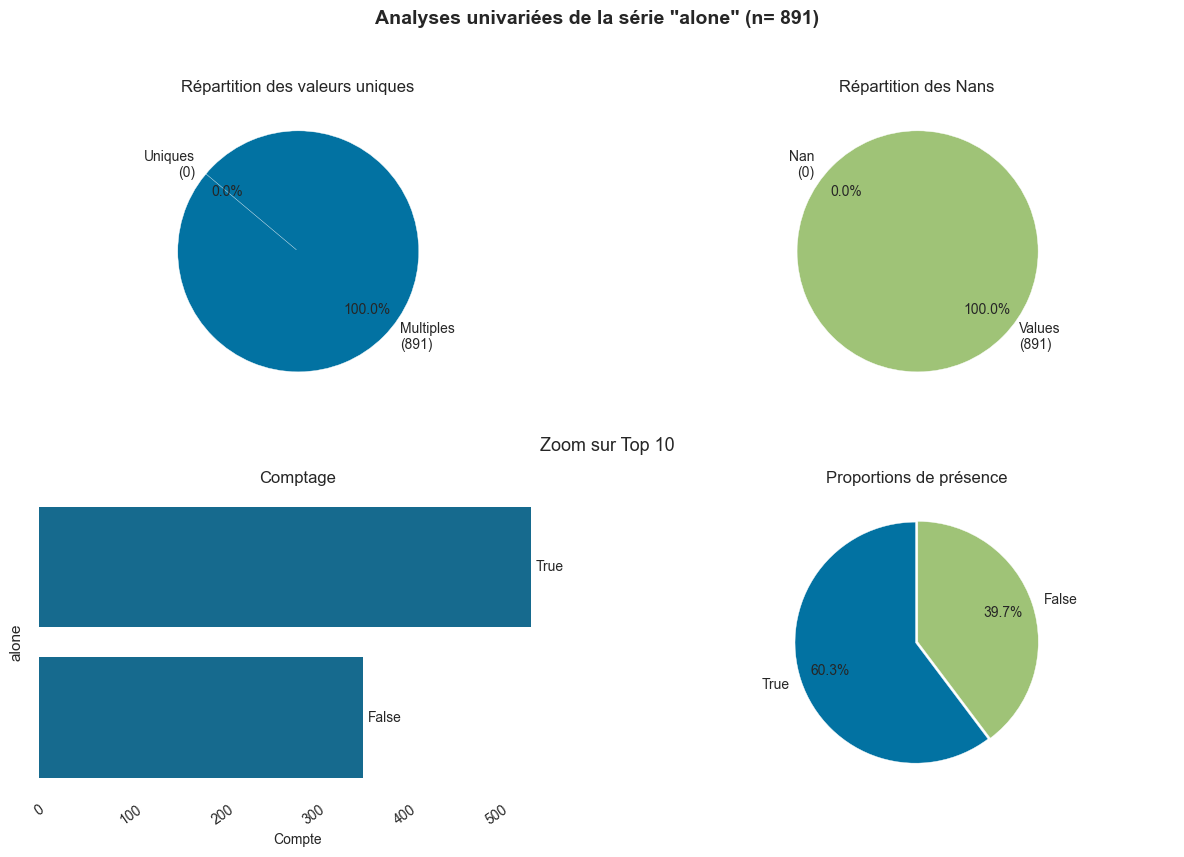
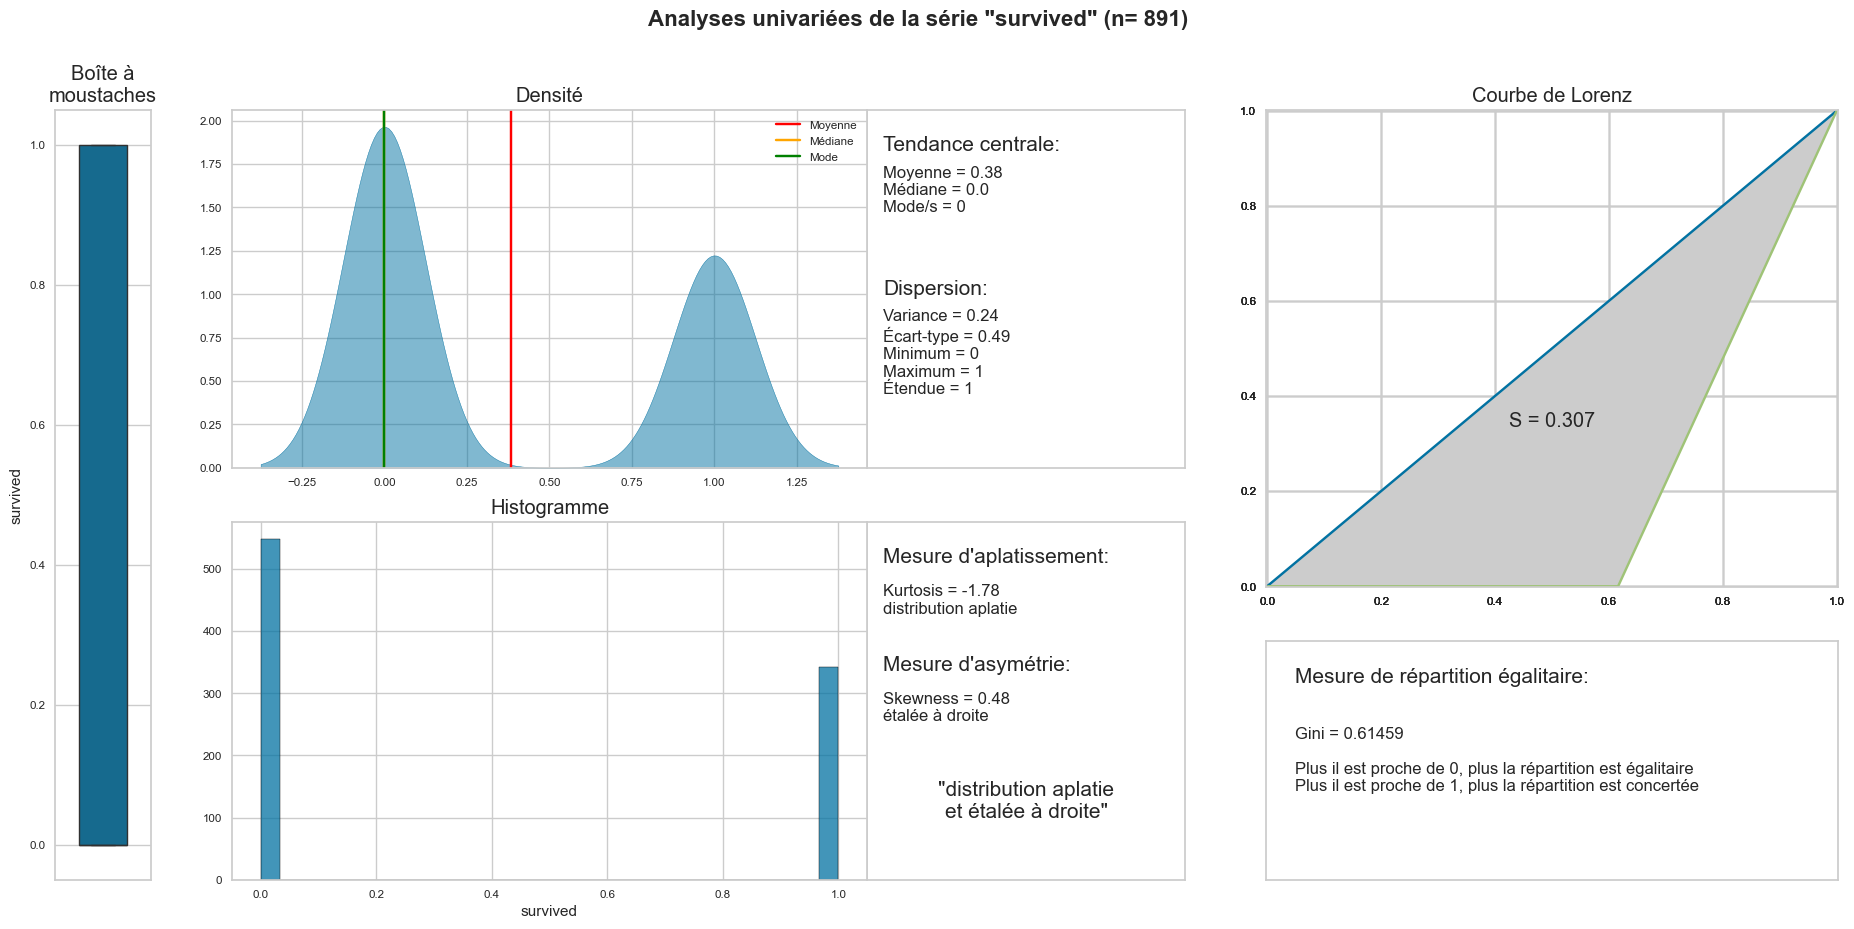

In [7]:
# Si vous ne voulez pas sauvegarder la figure il est possible de l'utiliser directement
StatUnivariee(df)


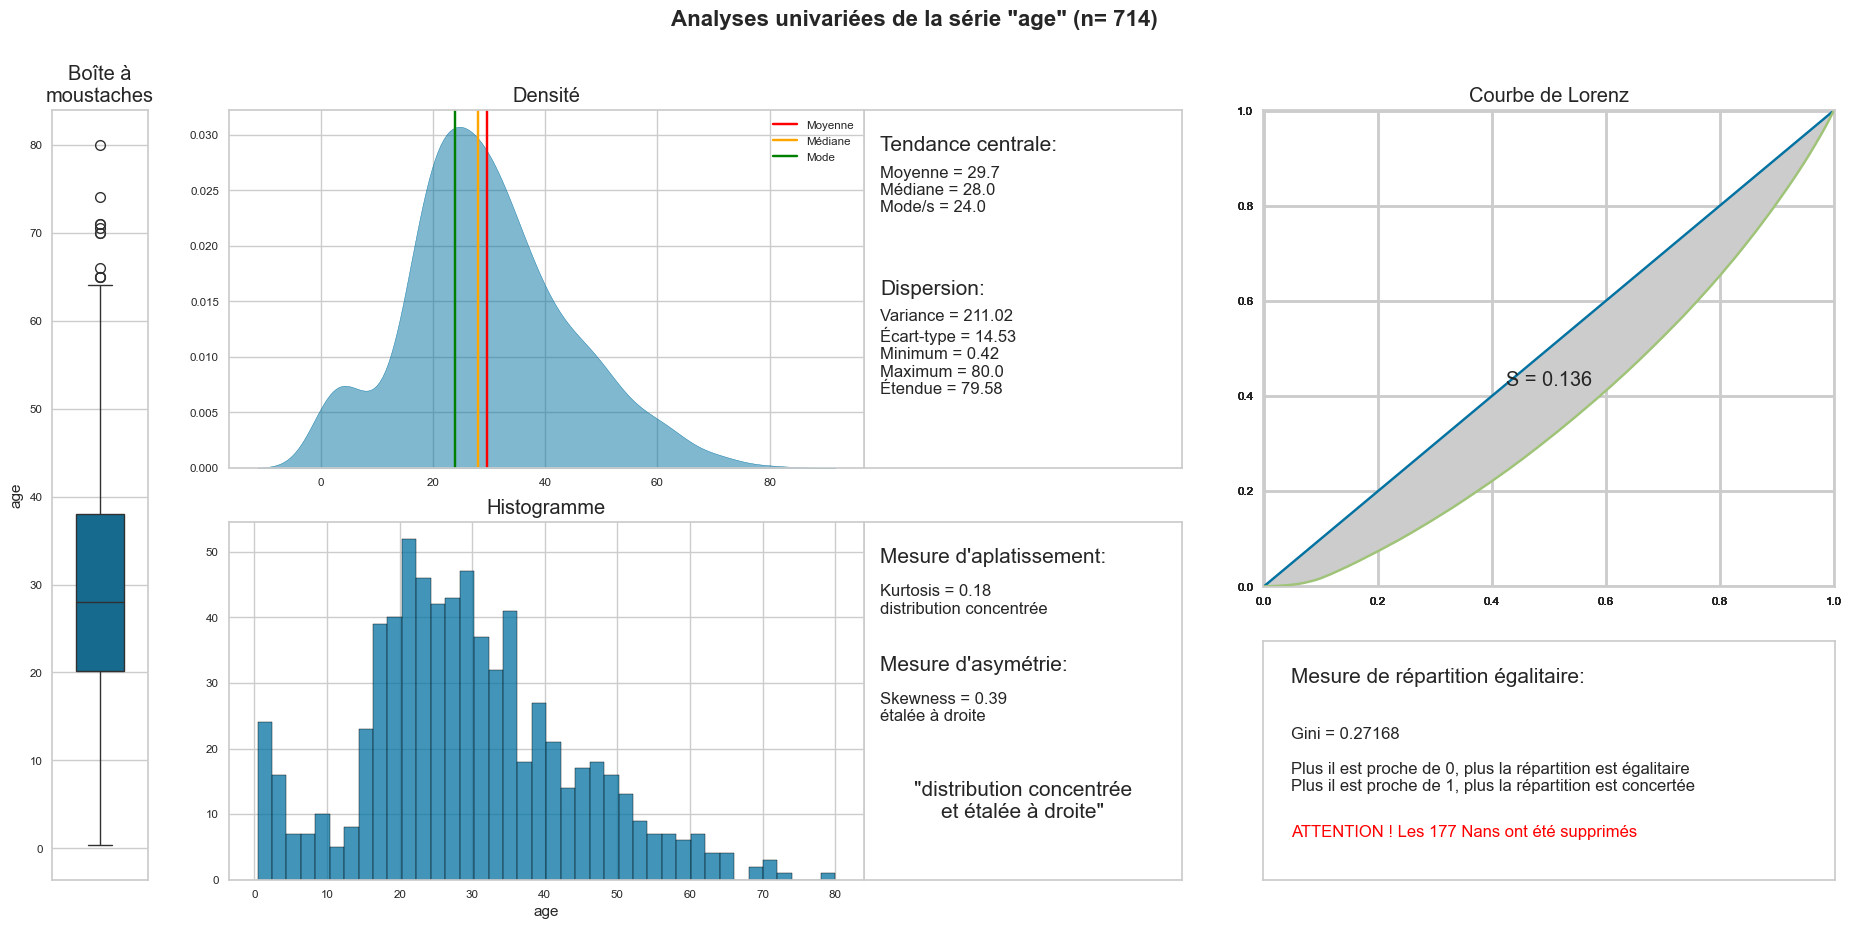
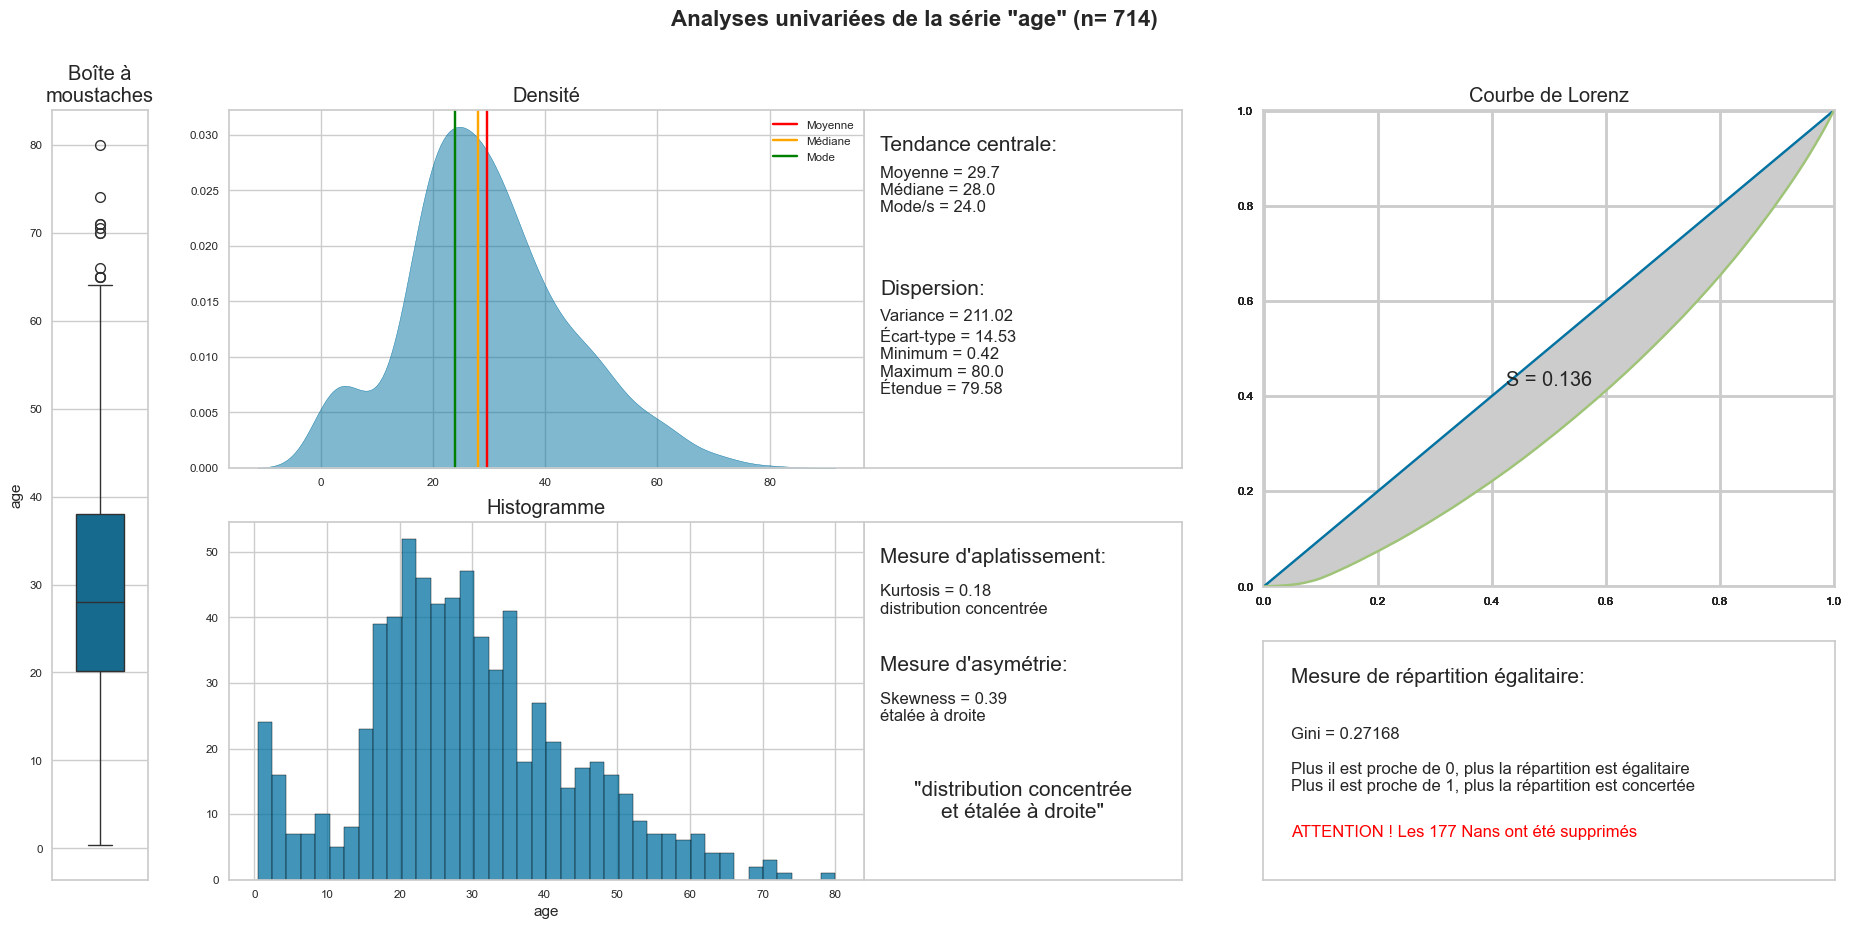

In [8]:
# Exemple de personnalisation de l'analyse univariée
StatUnivariee(df.age, hist_bins=40)


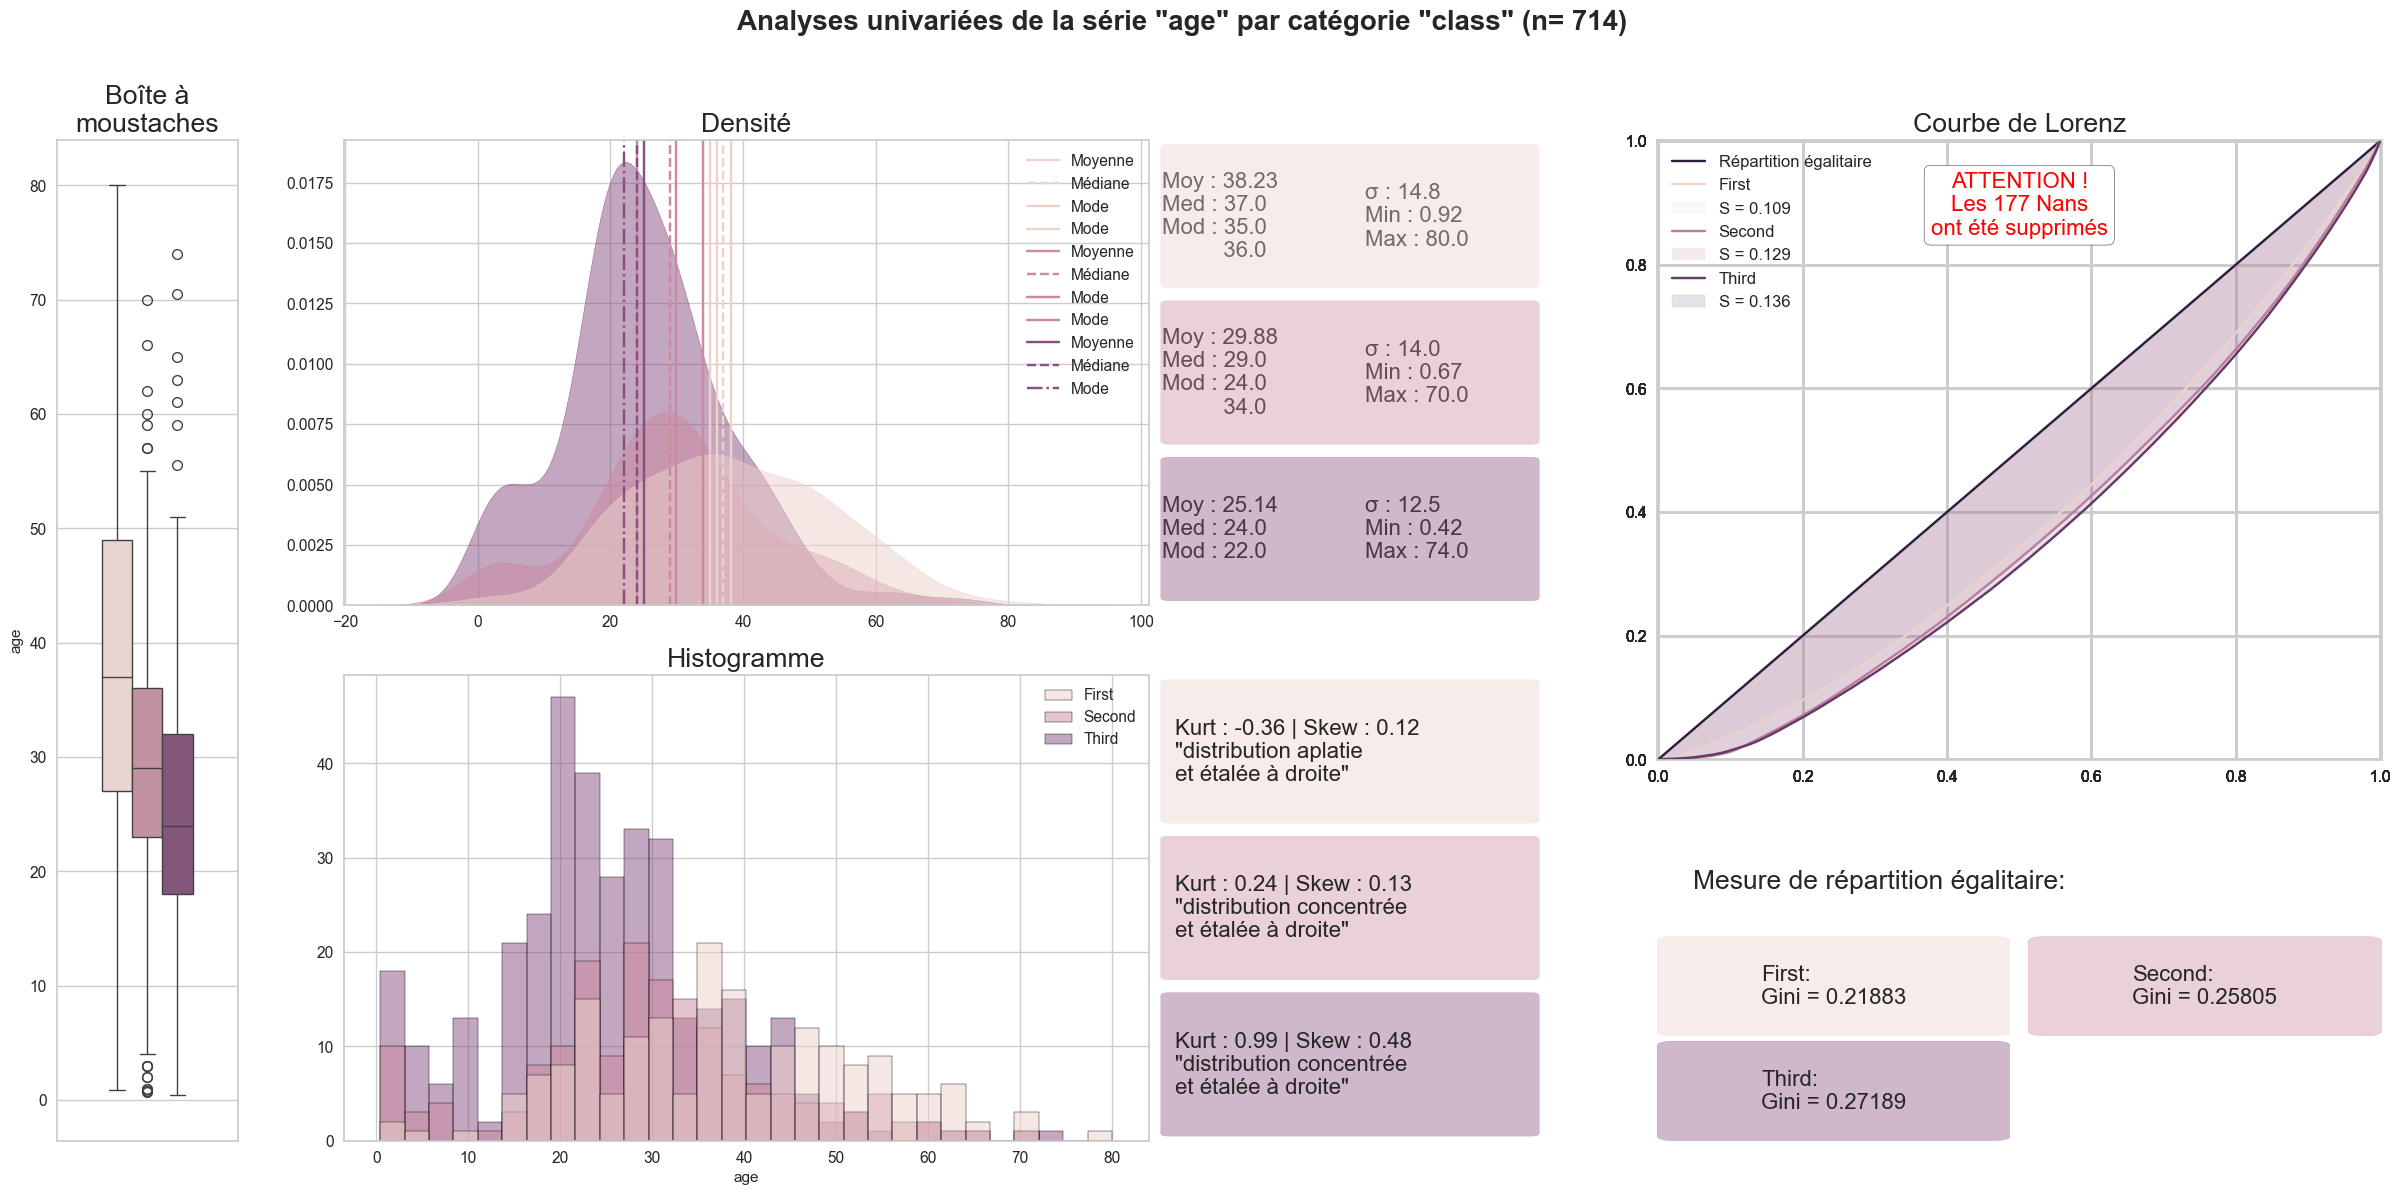
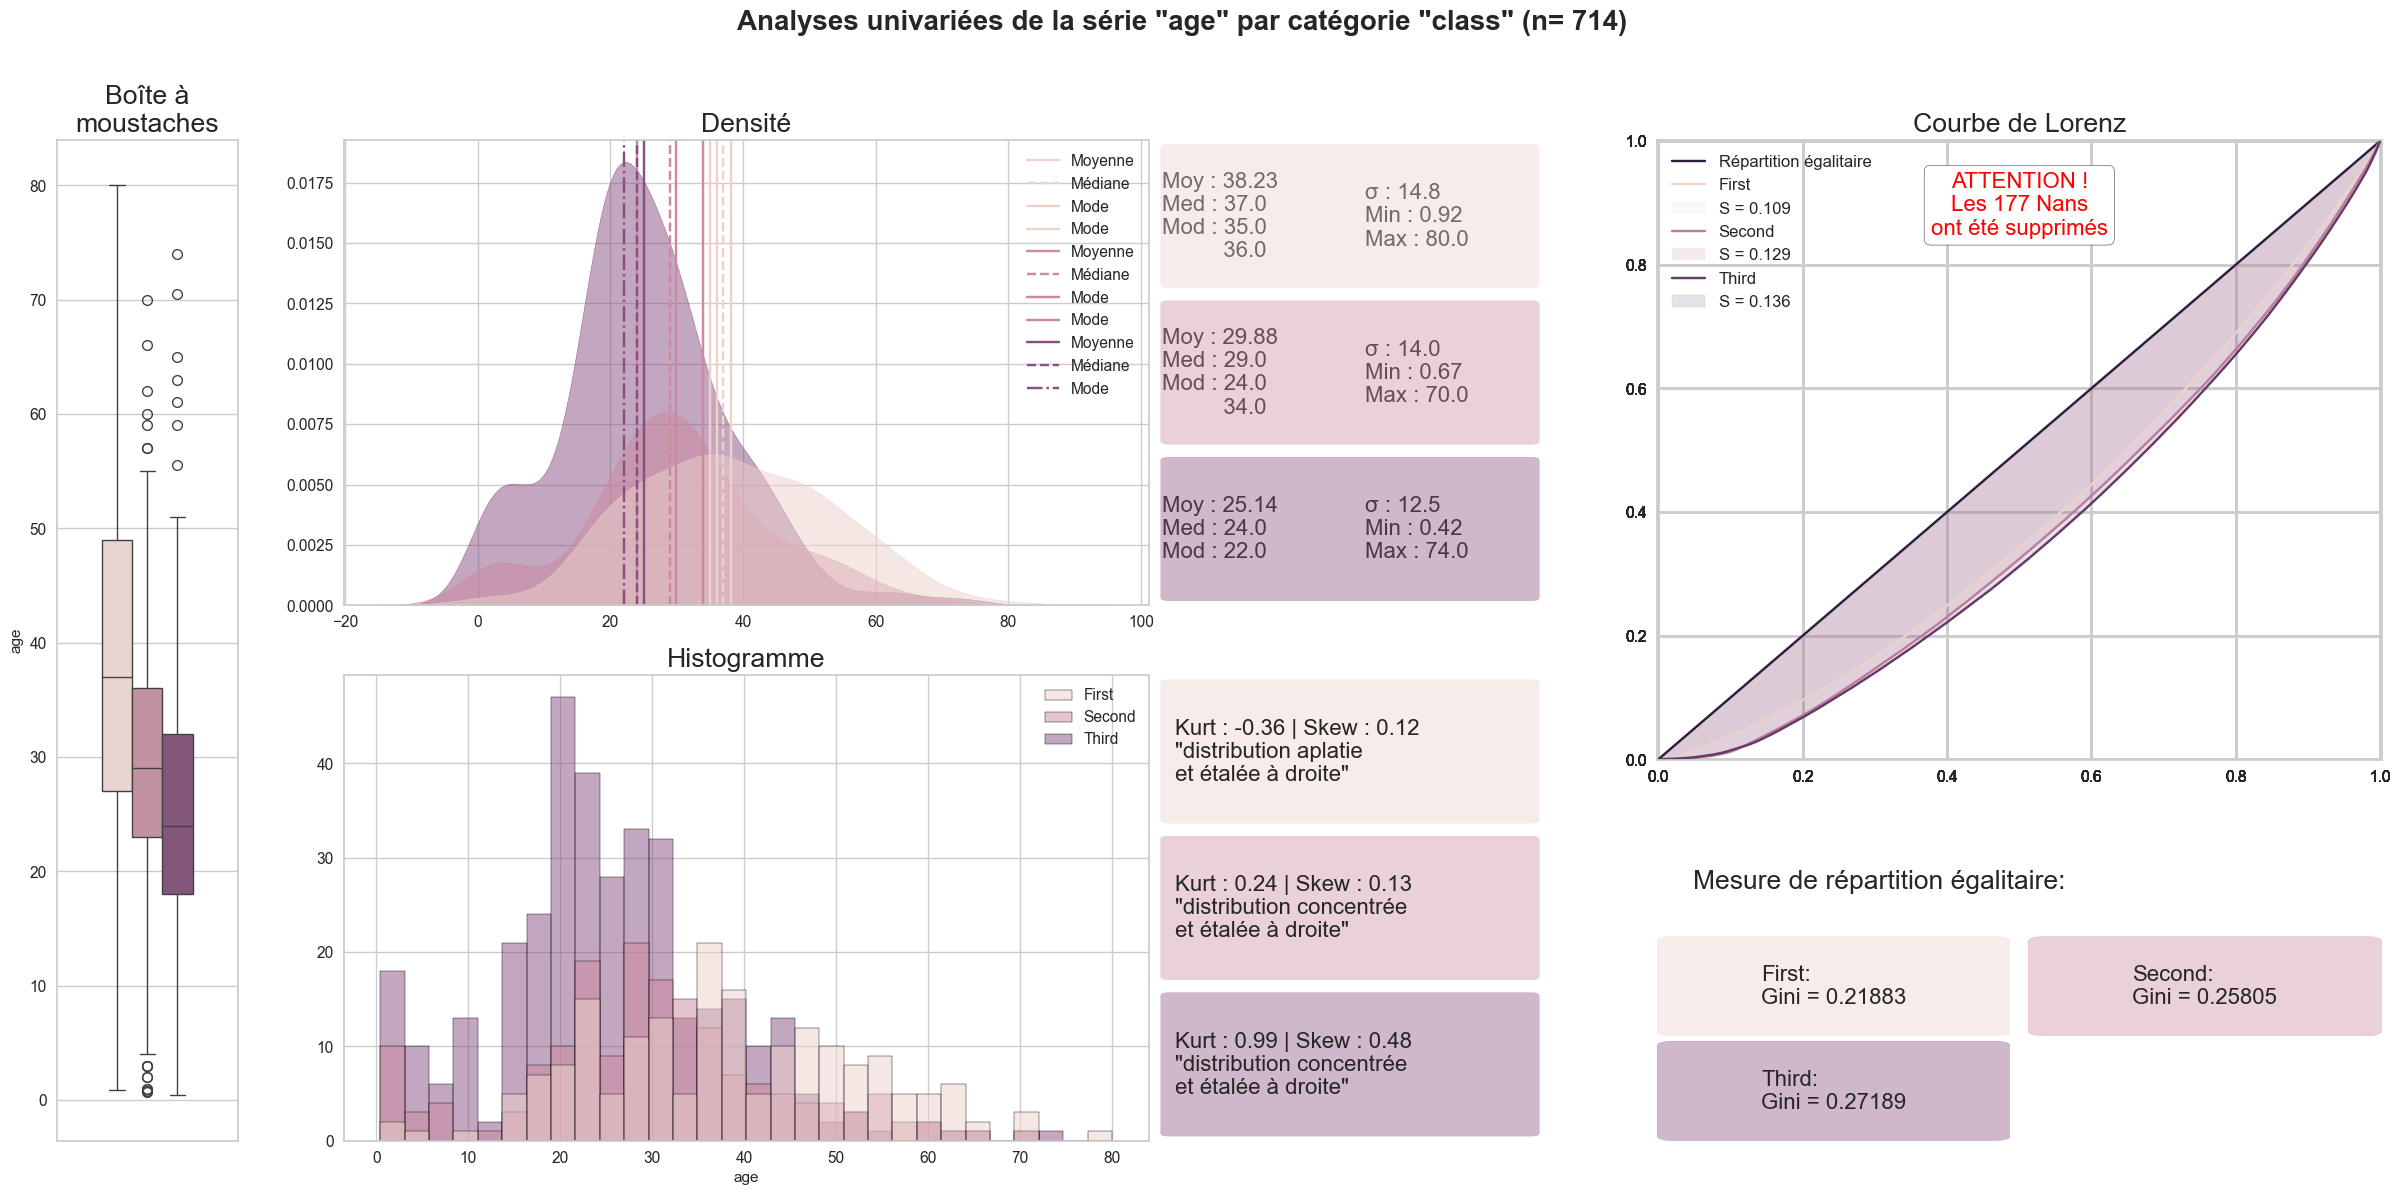

In [9]:
StatUnivariee(df.age, df['class'], figsize=(30, 13), text_frontsize=16, ratio_boxplot=1.5)


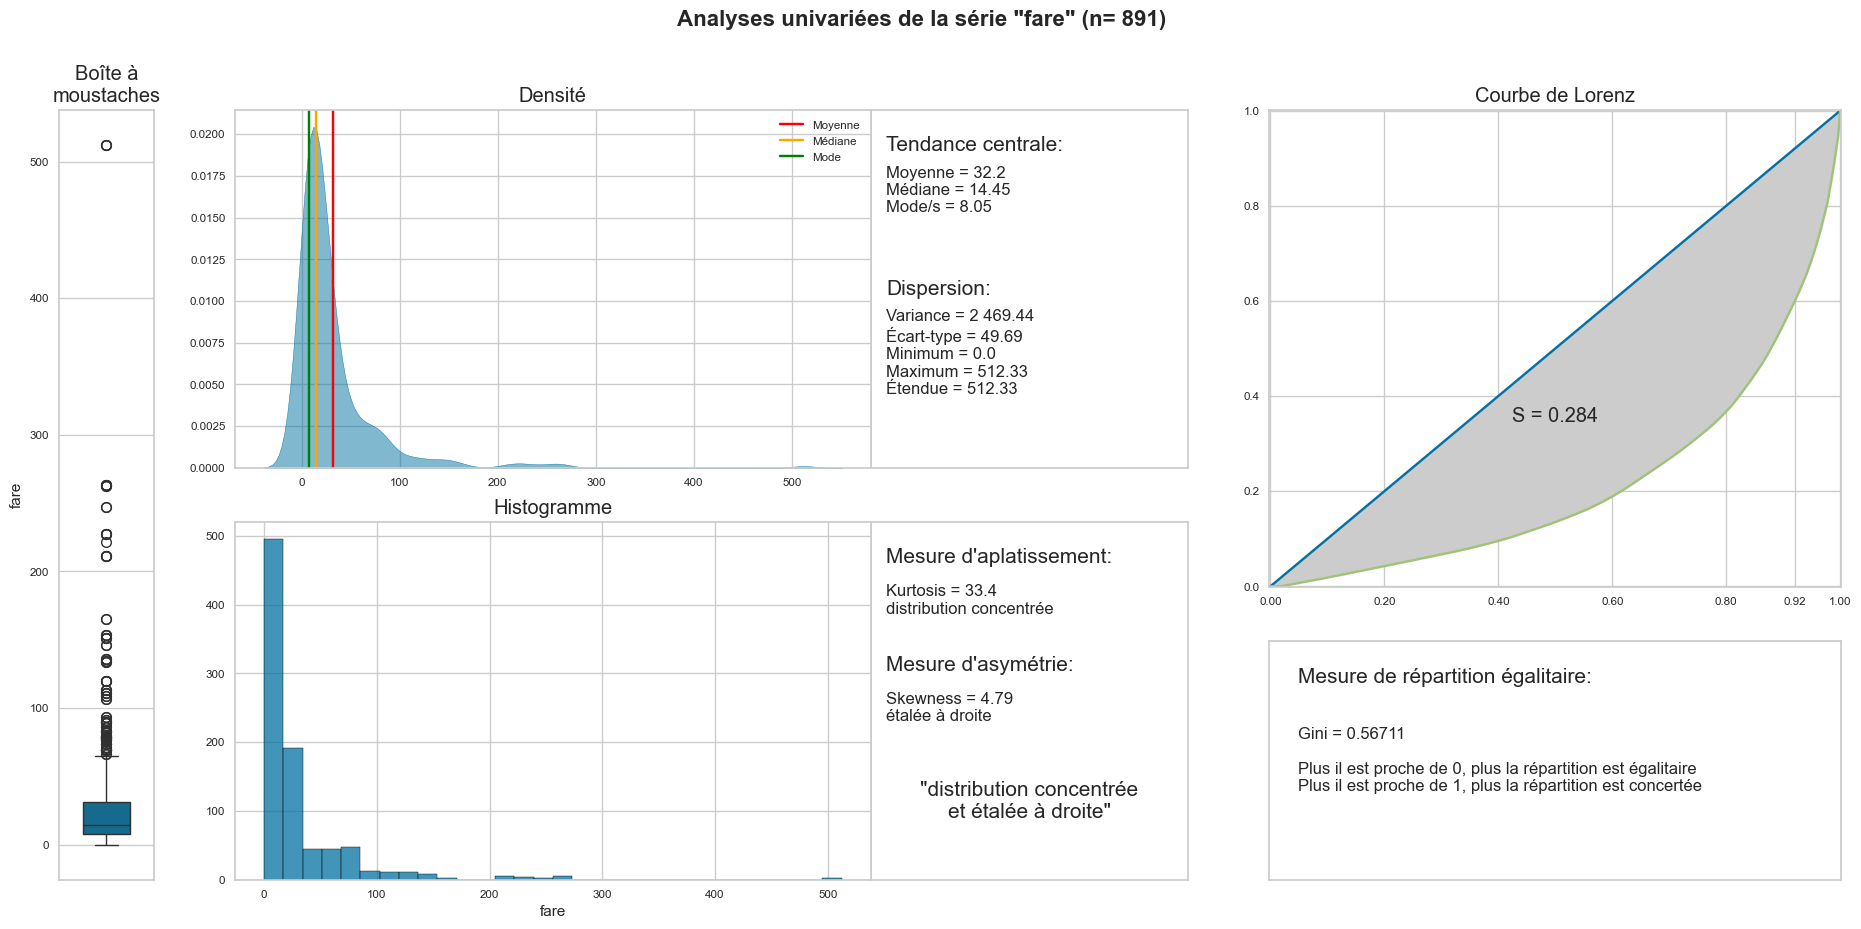
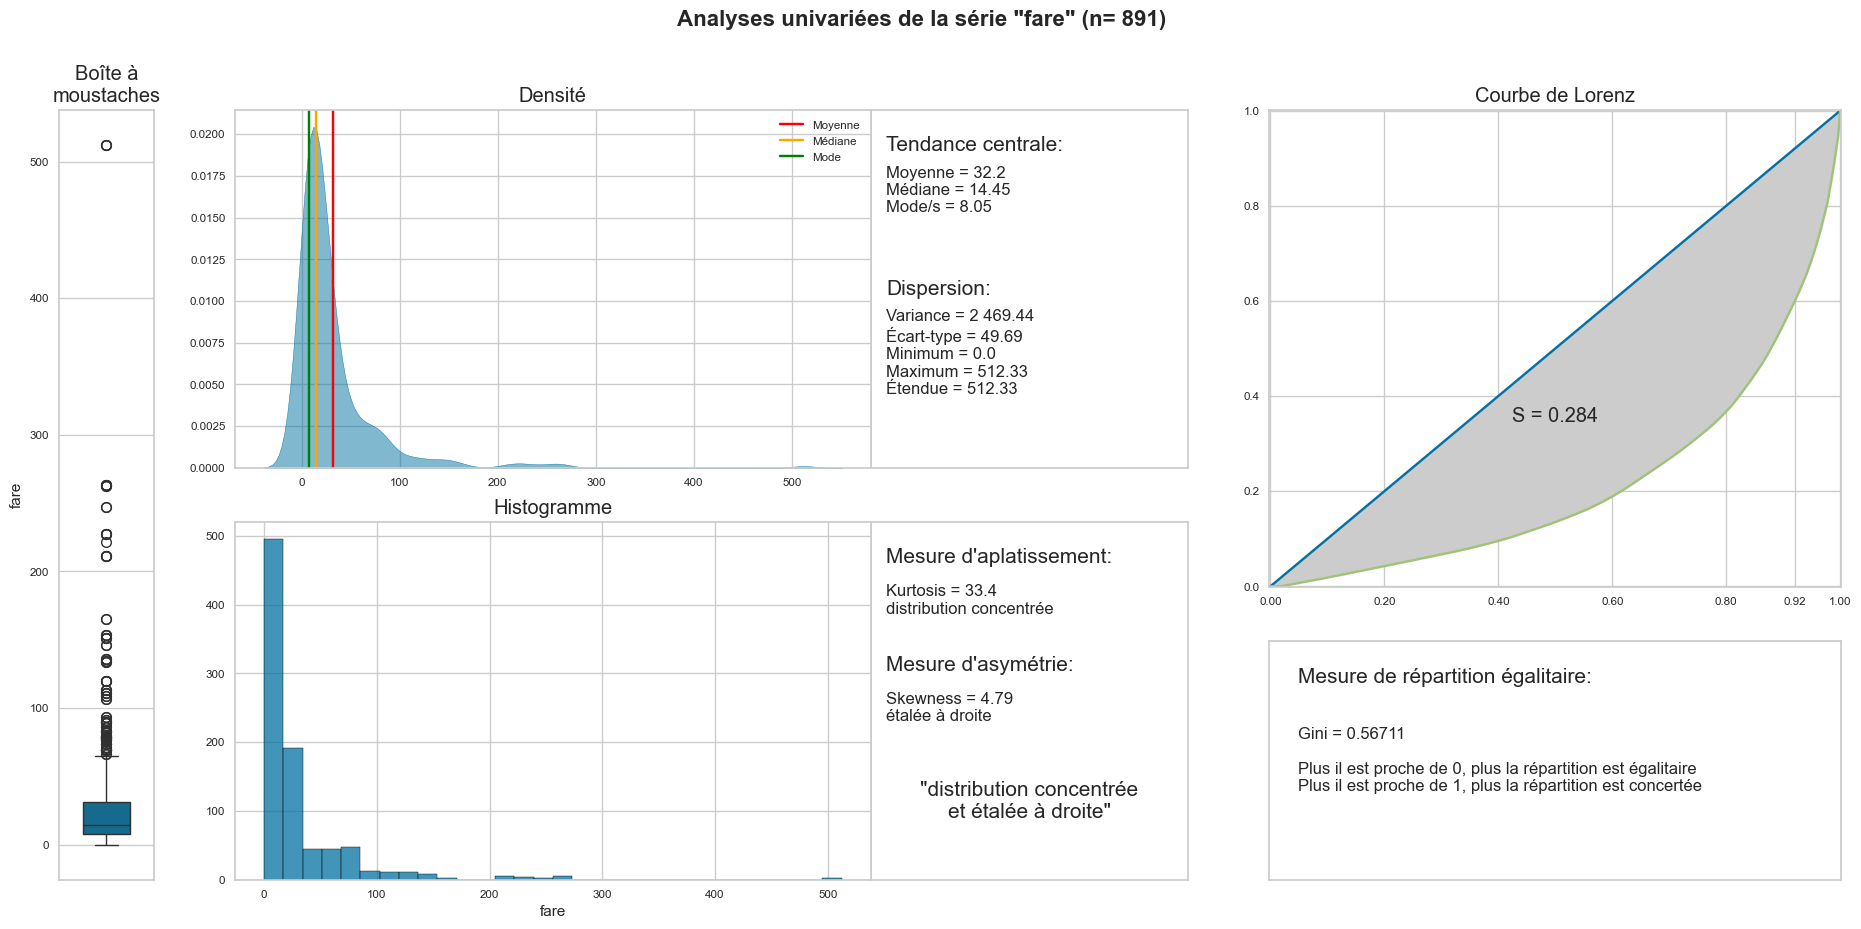

In [10]:
# Permet le traçage de marqueurs sur la courbe de Lorenz
StatUnivariee(df.fare, 
               lorenz_xticks=[0.92], 
               lorenz_yticks=[])